In [2]:
import glob
import os
import re
import sys
sys.path.append('/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/analysis/')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from ReadTrinity import read_cherenkov_hits, plot_GROPT, plot_CARE

# ── Config ─────────────────────────────────────────────────────────────────────
Zen_max = 92
Az_max = 280
PE_THRESHOLD = 20
DELTA_PE = 200

BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"

# Energy range in GeV (edit these)
ENERGY_MIN_GEV = 1e3
ENERGY_MAX_GEV = 1e5

# Optional event-parameter filters; set to None for no filtering
ZEN_FILTER = None
AZ_FILTER = None
HEIGHT_FILTER = None
TEL_X_FILTER = None
TEL_Z_FILTER = None
SEED_FILTER = None

particle_id = 13
radius = 5
y = 0

# CARE time window for peak slice (ns)
CARE_BIN_NS = 10.0

# Camera overlay on CORSIKA8 panel (meters)
CAMERA_RADIUS_M = 0.65


# ── File readers ───────────────────────────────────────────────────────────────
def read_specific_cherenkov_hits(pid, E_str, zen, az, h, x, y, z, r, seed):
    input_file = (f"/scratch/general/vast/u1520754/muon_sim_chain_tree/"
                  f"Muon_pid{pid}_E{E_str}_R{r}/pdg{pid}_E{E_str}_r{r}_s{seed}/"
                  f"zen{zen}/az{az}/h{h}/x{x}_y{y}_z{z}/CORSIKA8/cherenkov_hits.dat")
    X, Y, T, cos_X, cos_Y, wavelength, zem, Theta_z, Phi, Slant, Weight = \
        read_cherenkov_hits(input_file, plot=False)
    return X, Y, T, cos_X, cos_Y, wavelength, zem, Theta_z, Phi, Slant, Weight


def read_specific_GROPT(pid, E_str, zen, az, h, x, y, z, r, seed):
    input_file = (f"/scratch/general/vast/u1520754/muon_sim_chain_tree/"
                  f"Muon_pid{pid}_E{E_str}_R{r}/pdg{pid}_E{E_str}_r{r}_s{seed}/"
                  f"zen{zen}/az{az}/h{h}/x{x}_y{y}_z{z}/GROPT/cherenkov_hits.root")
    cosx, cosy, photonX_np, photonY_np, T = plot_GROPT(input_file, plot=False)
    photonx_np = -photonY_np
    photony_np = -photonX_np
    return cosx, cosy, photonx_np, photony_np, T


def read_specific_CARE(pid, E_str, zen, az, h, x, y, z, r, seed):
    input_file = (f"/scratch/general/vast/u1520754/muon_sim_chain_tree/"
                  f"Muon_pid{pid}_E{E_str}_R{r}/pdg{pid}_E{E_str}_r{r}_s{seed}/"
                  f"zen{zen}/az{az}/h{h}/x{x}_y{y}_z{z}/CARE/cherenkov_hits.root")
    camera_matrix, time_ns, total_pe, max_pe, arrays, pixel_config, \
        min_x, max_x, min_y, max_y, pixel_pitch = plot_CARE(input_file, plot=False)
    return camera_matrix, time_ns, total_pe, max_pe, arrays, pixel_config, \
        min_x, max_x, min_y, max_y, pixel_pitch


# ── Helpers ───────────────────────────────────────────────────────────────────
def parse_energy_from_dirname(dirname, pid, radius):
    pattern = rf"^Muon_pid{pid}_E(.+)_R{radius}$"
    m = re.match(pattern, dirname)
    return m.group(1) if m else None


def discover_energy_strings(pid, radius, base_dir=BASE_DIR):
    energies = []
    for name in os.listdir(base_dir):
        e_str = parse_energy_from_dirname(name, pid, radius)
        if e_str is not None:
            energies.append(e_str)
    return sorted(set(energies), key=lambda s: float(s))


def discover_scan_csvs(pid, energy_str, radius, base_dir=BASE_DIR):
    csv_glob = (f"{base_dir}/Muon_pid{pid}_E{energy_str}_R{radius}/csv_output/"
                f"scan_care_pid{pid}_E{energy_str}_R{radius}_y0_s*.csv")
    return sorted(glob.glob(csv_glob))


def parse_seed_from_csv_path(path):
    m = re.search(r"_s(\d+)\.csv$", path)
    return int(m.group(1)) if m else None


def normalize_path_number(val):
    f = float(val)
    if f == 0:
        return str(0)
    else:
        return str((round(f,1)))

def normalize_path_number_h(val):
    f = float(val)
    return str(int(round(f)))


def normalize_angle_number(val):
    return f"{float(val):.1f}"


def to_numeric_or_none(v):
    try:
        if pd.isna(v):
            return None
        return float(v)
    except Exception:
        return None


def row_matches_filters(row):
    checks = [
        ("zen", ZEN_FILTER),
        ("az", AZ_FILTER),
        ("height", HEIGHT_FILTER),
        ("tel_x", TEL_X_FILTER),
        ("tel_z", TEL_Z_FILTER),
    ]
    for col, allowed in checks:
        if allowed is None:
            continue
        v = to_numeric_or_none(row.get(col, np.nan))
        if v is None:
            return False
        if not any(np.isclose(v, float(a), atol=1e-6) for a in allowed):
            return False
    return True


def load_trigger_events(pid, radius, e_min, e_max, pe_threshold, base_dir=BASE_DIR):
    events = []
    all_energies = discover_energy_strings(pid, radius, base_dir=base_dir)
    for e_str in all_energies:
        e_val = float(e_str)
        if e_val < e_min or e_val > e_max:
            continue

        for csv_path in discover_scan_csvs(pid, e_str, radius, base_dir=base_dir):
            seed = parse_seed_from_csv_path(csv_path)
            if seed is None:
                continue
            if SEED_FILTER is not None and seed not in SEED_FILTER:
                continue

            try:
                df = pd.read_csv(csv_path)
            except Exception as exc:
                print(f"WARNING: failed reading {csv_path}: {exc}")
                continue

            if "file_found" in df.columns:
                df = df[df["file_found"] == 1].copy()
            for col in ["tel_x", "tel_z", "height", "zen", "az", "max_pe", "time_at_max_pe_ns"]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")

            if "max_pe" not in df.columns:
                continue
            df = df[df["max_pe"].fillna(-np.inf) >= pe_threshold].copy()
            df = df[df["max_pe"] <= pe_threshold+DELTA_PE].copy()
            for _, row in df.iterrows():
                if not row_matches_filters(row):
                    continue
                if any(pd.isna(row[c]) for c in ["zen", "az", "height", "tel_x", "tel_z"]):
                    continue
                if float(row["az"]) <= Az_max and  float(row["zen"]) <= Zen_max:
                    events.append({
                    "E_str": e_str,
                    "seed": int(seed),
                    "zen": float(row["zen"]),
                    "az": float(row["az"]),
                    "h": float(row["height"]),
                    "x": float(row["tel_x"]),
                    "z": float(row["tel_z"]),
                    "csv_max_pe": float(row["max_pe"]),
                })

    unique = {}
    for ev in events:
        key = (ev["E_str"], ev["seed"], ev["zen"], ev["az"], ev["h"], ev["x"], ev["z"])
        if key not in unique:
            unique[key] = ev
    return list(unique.values())


def hist2d_matrix(x_data, y_data, bins, x_range, y_range, weights=None):
    H, xedges, yedges = np.histogram2d(
        x_data, y_data, bins=bins, range=[x_range, y_range], weights=weights
    )
    return H.T, xedges, yedges


def build_care_grid_at_peak(arrays, pixel_config, min_x, min_y, pixel_pitch, time_ns):
    dc_to_pe = 24.1
    baseline_dc = 500

    all_traces_pe = {}
    for pix_id in range(256):
        trace_name = f"vFADCTraces{pix_id}"
        if trace_name in arrays:
            trace_dc = arrays[trace_name][0]
            trace_pe = np.clip((trace_dc - baseline_dc) / dc_to_pe, 0, None)
            all_traces_pe[pix_id] = trace_pe

    if not all_traces_pe:
        return np.zeros((16, 16)), 0.0, 0

    total_pe_trace = np.sum(np.array(list(all_traces_pe.values())), axis=0)
    peak_idx = int(np.argmax(total_pe_trace))
    peak_time_ns = float(time_ns[peak_idx])

    t_lo = peak_time_ns - CARE_BIN_NS / 2.0
    t_hi = peak_time_ns + CARE_BIN_NS / 2.0
    sample_indices = np.where((time_ns >= t_lo) & (time_ns < t_hi))[0]

    if len(sample_indices) == 0:
        sample_indices = np.array([peak_idx], dtype=int)

    grid = np.zeros((16, 16))
    for pix_id in range(256):
        if pix_id in all_traces_pe:
            pe_val = np.sum(all_traces_pe[pix_id][sample_indices])
            x_pos = pixel_config[pix_id][1]
            y_pos = pixel_config[pix_id][2]
            col = int((x_pos - min_x) / pixel_pitch)
            row = int((y_pos - min_y) / pixel_pitch)
            if 0 <= row < 16 and 0 <= col < 16:
                grid[row, col] = pe_val

    return grid, peak_time_ns, peak_idx


# ── Build events from trigger CSV ─────────────────────────────────────────────
trigger_events = load_trigger_events(
    pid=particle_id,
    radius=radius,
    e_min=ENERGY_MIN_GEV,
    e_max=ENERGY_MAX_GEV,
    pe_threshold=PE_THRESHOLD,
    base_dir=BASE_DIR,
 )

if not trigger_events:
    raise RuntimeError("No triggered events found for selected range/filters.")

print(f"Found {len(trigger_events)} triggered events from CSV.")
# ── Random sampling of trigger events (optional) ────────────────────────────────
SAMPLING_FRACTION = 0.5  # Sample 10% of events; set to 1.0 to use all

np.random.seed(42)  # for reproducibility
n_total = len(trigger_events)
n_sample = max(1, int(n_total * SAMPLING_FRACTION))

if SAMPLING_FRACTION < 1.0:
    sampled_indices = np.random.choice(n_total, size=n_sample, replace=False)
    trigger_events = [trigger_events[i] for i in sorted(sampled_indices)]
    print(f"Randomly sampled {len(trigger_events)} events ({SAMPLING_FRACTION*100:.1f}% of {n_total})")
else:
    print(f"Using all {n_total} events (SAMPLING_FRACTION={SAMPLING_FRACTION})")

Found 18915 triggered events from CSV.
Randomly sampled 9457 events (50.0% of 18915)


In [3]:
import numpy as np
# ── Config for input building ─────────────────────────────────────────────────
DC_TO_PE = 24.1
BASELINE_DC = 500
PE_NORM = 150.0          # divide all PE by this
particle_id =13
PE_THRESHOLD =20
radius =5

CACHE_PATH = ("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/"
              f"cache/care_cube_pid{particle_id}_E{ENERGY_MIN_GEV:.3g}-"
              f"{ENERGY_MAX_GEV:.3g}_R{radius}_thr{PE_THRESHOLD:.0f}_sz{SAMPLING_FRACTION}.npz")


def build_care_cube_full(arrays, pixel_config, min_x, min_y, pixel_pitch):
    """Return full (T, 16, 16) PE cube using ALL FADC samples."""
    # collect per-pixel PE traces
    pix_traces = {}
    trace_len = None
    for pix_id in range(256):
        tname = f"vFADCTraces{pix_id}"
        if tname in arrays:
            trace_dc = np.asarray(arrays[tname][0], dtype=float)
            trace_pe = np.clip((trace_dc - BASELINE_DC) / DC_TO_PE, 0, None)
            pix_traces[pix_id] = trace_pe
            if trace_len is None:
                trace_len = len(trace_pe)

    if trace_len is None:
        return np.zeros((1, 16, 16), dtype=np.float32)

    cube = np.zeros((trace_len, 16, 16), dtype=np.float32)
    for pix_id, trace_pe in pix_traces.items():
        x_pos = pixel_config[pix_id][1]
        y_pos = pixel_config[pix_id][2]
        col = int((x_pos - min_x) / pixel_pitch)
        row = int((y_pos - min_y) / pixel_pitch)
        if 0 <= row < 16 and 0 <= col < 16:
            L = min(len(trace_pe), trace_len)
            cube[:L, row, col] = trace_pe[:L]
    return cube


# ── Build cubes + targets for all triggered events ────────────────────────────
cube_list = []
target_list = []          # [log10E, zen, az, x, z]
meta_list = []            # keep labels for bookkeeping
trace_lengths = []

for idx, ev in enumerate(trigger_events):
    E_str = ev["E_str"]
    s = ev["seed"]
    zen_s = normalize_angle_number(ev["zen"])
    az_s = normalize_angle_number(ev["az"])
    h_s = normalize_path_number_h(ev["h"])
    x_s = normalize_path_number(ev["x"])
    z_s = normalize_path_number(ev["z"])

    print(f"  [{idx+1}/{len(trigger_events)}] E={E_str} s={s} "
          f"zen={zen_s} az={az_s} x={x_s} z={z_s}")

    try:
        camera_matrix, time_ns, total_pe, max_pe, arrays, pixel_config, \
            min_x_c, max_x_c, min_y_c, max_y_c, pixel_pitch = read_specific_CARE(
            pid=particle_id, E_str=E_str, zen=zen_s, az=az_s,
            h=h_s, x=x_s, y=y, z=z_s, r=radius, seed=s)

        cube = build_care_cube_full(
            arrays, pixel_config, min_x_c, min_y_c, pixel_pitch)

        cube_list.append(cube)
        trace_lengths.append(cube.shape[0])
        target_list.append([
            np.log10(float(E_str)),   # log10 Energy [GeV]
            float(ev["zen"]),         # zenith [deg]
            float(ev["az"]),          # azimuth [deg]
            float(ev["x"]),           # tel_x [m]
            float(ev["z"]),           # tel_z [m]
        ])
        meta_list.append(dict(E_str=E_str, seed=s, zen=ev["zen"], az=ev["az"],
                              h=ev["h"], x=ev["x"], z=ev["z"]))
    except Exception as e:
        print(f"    WARNING SKIPPED: {e}")

if not cube_list:
    raise RuntimeError("No valid triggered events could be loaded.")

# ── Pad/truncate all cubes to common T_max ────────────────────────────────────
T_max = max(trace_lengths)
print(f"Max trace length (T_max) = {T_max}; padding all cubes to this.")

N = len(cube_list)
X = np.zeros((N, T_max, 16, 16), dtype=np.float32)
for i, cube in enumerate(cube_list):
    T = min(cube.shape[0], T_max)
    X[i, :T] = cube[:T]

# normalize PE
X /= PE_NORM

y_targets = np.asarray(target_list, dtype=np.float32)   # (N, 5)

print(f"Input tensor X: {X.shape}  (N, T, 16, 16)")
print(f"Target tensor y: {y_targets.shape}  [log10E, zen, az, x, z]")

  [1/9457] E=1.12202e3 s=1 zen=88.8 az=269.4 x=0 z=0


  [2/9457] E=1.12202e3 s=1 zen=88.8 az=269.4 x=-0.2 z=-0.9


KeyboardInterrupt: 

In [ ]:
# ── Data augmentation: flip azimuth and zenith ─────────────────────────────────
print("\n" + "="*80)
print("DATA AUGMENTATION: Flipping azimuth and/or zenith axes")
print("="*80)
CACHE_PATH = ("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/"
              f"cache/care_cube_pid{particle_id}_E{ENERGY_MIN_GEV:.3g}-"
              f"{ENERGY_MAX_GEV:.3g}_R{radius}_thr{PE_THRESHOLD:.0f}_sz{SAMPLING_FRACTION}.npz")
AZIMUTH_REF = 270.0   # reference azimuth (telescope pointing direction)
ZENITH_REF = 90.0     # reference zenith (telescope pointing direction)

# ── Flip Azimuth (mirror in x-axis) ────────────────────────────────────────────
print("\n1. Creating azimuth-flipped dataset...")
X_flipped_az = np.zeros_like(X)
y_flipped_az = y_targets.copy()
meta_flipped_az = []

for i in range(N):
    X_flipped_az[i] = np.flip(X[i], axis=1)  # flip axis=1 (rows)
    
    old_az = y_targets[i, 2]
    new_az = (2 * AZIMUTH_REF - old_az) % 360.0
    y_flipped_az[i, 2] = new_az
    y_flipped_az[i, 3] = -y_targets[i, 3]  # flip x
    
    old_meta = meta_list[i].copy()
    old_meta['x'] = -old_meta['x']
    old_meta['az'] = new_az
    old_meta['augmented'] = 'azimuth'
    meta_flipped_az.append(old_meta)

# ── Flip Zenith (mirror in z-axis) ─────────────────────────────────────────────
print("2. Creating zenith-flipped dataset...")
X_flipped_zen = np.zeros_like(X)
y_flipped_zen = y_targets.copy()
meta_flipped_zen = []

for i in range(N):
    X_flipped_zen[i] = np.flip(X[i], axis=2)  # flip axis=2 (columns)
    
    old_zen = y_targets[i, 1]
    new_zen = np.clip(2 * ZENITH_REF - old_zen, 0, 180)
    y_flipped_zen[i, 1] = new_zen
    y_flipped_zen[i, 4] = -y_targets[i, 4]  # flip z
    
    old_meta = meta_list[i].copy()
    old_meta['z'] = -old_meta['z']
    old_meta['zen'] = new_zen
    old_meta['augmented'] = 'zenith'
    meta_flipped_zen.append(old_meta)

# ── Flip Both Azimuth AND Zenith (mirror in both x and y axes) ─────────────────
print("3. Creating azimuth+zenith-flipped dataset...")
X_flipped_both = np.zeros_like(X)
y_flipped_both = y_targets.copy()
meta_flipped_both = []

for i in range(N):
    # Flip both axes: x-axis (columns) and y-axis (rows)
    X_flipped_both[i] = np.flip(np.flip(X[i], axis=1), axis=2)
    
    # Flip azimuth
    old_az = y_targets[i, 2]
    new_az = (2 * AZIMUTH_REF - old_az) % 360.0
    y_flipped_both[i, 2] = new_az
    y_flipped_both[i, 3] = -y_targets[i, 3]  # flip x
    
    # Flip zenith
    old_zen = y_targets[i, 1]
    new_zen = np.clip(2 * ZENITH_REF - old_zen, 0, 180)
    y_flipped_both[i, 1] = new_zen
    y_flipped_both[i, 4] = -y_targets[i, 4]  # flip z
    
    old_meta = meta_list[i].copy()
    old_meta['x'] = -old_meta['x']
    old_meta['z'] = -old_meta['z']
    old_meta['az'] = new_az
    old_meta['zen'] = new_zen
    old_meta['augmented'] = 'both'
    meta_flipped_both.append(old_meta)

print(f"Original dataset size: {N} events")
print(f"Azimuth-flipped dataset size: {N} events")
print(f"Zenith-flipped dataset size: {N} events")
print(f"Both-flipped dataset size: {N} events")

# Show some examples
print("\nAugmentation examples:")
for i in range(min(2, N)):
    print(f"  Event {i}:")
    print(f"    Original:           az={y_targets[i, 2]:.1f}°, zen={y_targets[i, 1]:.1f}°, x={y_targets[i, 3]:.2f}m, z={y_targets[i, 4]:.2f}m")
    print(f"    Flipped Azimuth:    az={y_flipped_az[i, 2]:.1f}°, zen={y_flipped_az[i, 1]:.1f}°, x={y_flipped_az[i, 3]:.2f}m, z={y_flipped_az[i, 4]:.2f}m")
    print(f"    Flipped Zenith:     az={y_flipped_zen[i, 2]:.1f}°, zen={y_flipped_zen[i, 1]:.1f}°, x={y_flipped_zen[i, 3]:.2f}m, z={y_flipped_zen[i, 4]:.2f}m")
    print(f"    Flipped Both:       az={y_flipped_both[i, 2]:.1f}°, zen={y_flipped_both[i, 1]:.1f}°, x={y_flipped_both[i, 3]:.2f}m, z={y_flipped_both[i, 4]:.2f}m")

# ── Save original dataset to cache ─────────────────────────────────────────────
import os
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
np.savez_compressed(
    CACHE_PATH,
    X=X,
    y=y_targets,
    target_names=np.array(["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]),
    trace_lengths=np.array(trace_lengths),
    meta=np.array(meta_list, dtype=object),
    pe_norm=PE_NORM,
    T_max=T_max,
)
print(f"\nSaved original cached dataset to '{CACHE_PATH}'")

# ── Save individual flipped datasets ───────────────────────────────────────────
CACHE_PATH_FLIPPED_AZ = CACHE_PATH.replace(".npz", "_flipped_Azimuth.npz")
np.savez_compressed(
    CACHE_PATH_FLIPPED_AZ,
    X=X_flipped_az,
    y=y_flipped_az,
    target_names=np.array(["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]),
    trace_lengths=np.array(trace_lengths),
    meta=np.array(meta_flipped_az, dtype=object),
    pe_norm=PE_NORM,
    T_max=T_max,
)
print(f"Saved azimuth-flipped cached dataset to '{CACHE_PATH_FLIPPED_AZ}'")

CACHE_PATH_FLIPPED_ZEN = CACHE_PATH.replace(".npz", "_flipped_Zenith.npz")
np.savez_compressed(
    CACHE_PATH_FLIPPED_ZEN,
    X=X_flipped_zen,
    y=y_flipped_zen,
    target_names=np.array(["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]),
    trace_lengths=np.array(trace_lengths),
    meta=np.array(meta_flipped_zen, dtype=object),
    pe_norm=PE_NORM,
    T_max=T_max,
)
print(f"Saved zenith-flipped cached dataset to '{CACHE_PATH_FLIPPED_ZEN}'")

CACHE_PATH_FLIPPED_BOTH = CACHE_PATH.replace(".npz", "_flipped_Both.npz")
np.savez_compressed(
    CACHE_PATH_FLIPPED_BOTH,
    X=X_flipped_both,
    y=y_flipped_both,
    target_names=np.array(["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]),
    trace_lengths=np.array(trace_lengths),
    meta=np.array(meta_flipped_both, dtype=object),
    pe_norm=PE_NORM,
    T_max=T_max,
)
print(f"Saved both-flipped cached dataset to '{CACHE_PATH_FLIPPED_BOTH}'")

# ── Create combined dataset (original + all flipped) ────────────────────────────
print("\n4. Creating combined dataset...")
X_combined = np.vstack([X, X_flipped_az, X_flipped_zen, X_flipped_both])
y_combined = np.vstack([y_targets, y_flipped_az, y_flipped_zen, y_flipped_both])
meta_combined = meta_list + meta_flipped_az + meta_flipped_zen + meta_flipped_both
trace_lengths_combined = trace_lengths + trace_lengths + trace_lengths + trace_lengths

N_combined = len(X_combined)

CACHE_PATH_COMBINED = CACHE_PATH.replace(".npz", "_combined.npz")
np.savez_compressed(
    CACHE_PATH_COMBINED,
    X=X_combined,
    y=y_combined,
    target_names=np.array(["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]),
    trace_lengths=np.array(trace_lengths_combined),
    meta=np.array(meta_combined, dtype=object),
    pe_norm=PE_NORM,
    T_max=T_max,
)
print(f"Saved combined cached dataset to '{CACHE_PATH_COMBINED}'")

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"Original:           {CACHE_PATH}")
print(f"  Size: {X.shape}")
print(f"\nFlipped Azimuth:    {CACHE_PATH_FLIPPED_AZ}")
print(f"  Size: {X_flipped_az.shape}")
print(f"  Changes: x→-x, az→{2*AZIMUTH_REF}°-az, grid flipped on x-axis")
print(f"\nFlipped Zenith:     {CACHE_PATH_FLIPPED_ZEN}")
print(f"  Size: {X_flipped_zen.shape}")
print(f"  Changes: z→-z, zen→{2*ZENITH_REF}°-zen, grid flipped on y-axis")
print(f"\nFlipped Both:       {CACHE_PATH_FLIPPED_BOTH}")
print(f"  Size: {X_flipped_both.shape}")
print(f"  Changes: x→-x, z→-z, az→{2*AZIMUTH_REF}°-az, zen→{2*ZENITH_REF}°-zen, grid flipped on both axes")
print(f"\nCombined:           {CACHE_PATH_COMBINED}")
print(f"  Size: {X_combined.shape}")
print(f"  Contains: Original ({N}) + Az ({N}) + Zen ({N}) + Both ({N}) = {N_combined} total")
print("="*80)


DATA AUGMENTATION: Flipping azimuth and/or zenith axes

1. Creating azimuth-flipped dataset...
2. Creating zenith-flipped dataset...
3. Creating azimuth+zenith-flipped dataset...
Original dataset size: 8386 events
Azimuth-flipped dataset size: 8386 events
Zenith-flipped dataset size: 8386 events
Both-flipped dataset size: 8386 events

Augmentation examples:
  Event 0:
    Original:           az=269.4°, zen=88.8°, x=0.00m, z=0.00m
    Flipped Azimuth:    az=270.6°, zen=88.8°, x=-0.00m, z=0.00m
    Flipped Zenith:     az=269.4°, zen=91.2°, x=0.00m, z=-0.00m
    Flipped Both:       az=270.6°, zen=91.2°, x=-0.00m, z=-0.00m
  Event 1:
    Original:           az=269.4°, zen=88.8°, x=-0.20m, z=-0.90m
    Flipped Azimuth:    az=270.6°, zen=88.8°, x=0.20m, z=-0.90m
    Flipped Zenith:     az=269.4°, zen=91.2°, x=-0.20m, z=0.90m
    Flipped Both:       az=270.6°, zen=91.2°, x=0.20m, z=0.90m

Saved original cached dataset to '/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/cache/care_cube_

In [ ]:
Test_M = M[100].reshape(200,256)*150*24.1
np.mean(Test_M[0:5])

np.float32(15.097656)

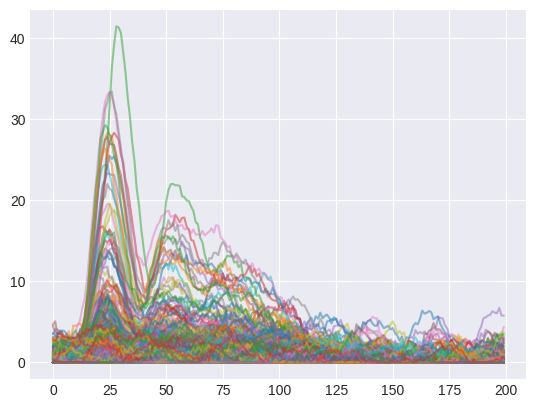

In [ ]:
plt.plot(M[8].reshape(200,256)*150, alpha =0.5)
plt.show()

91.5 270.0


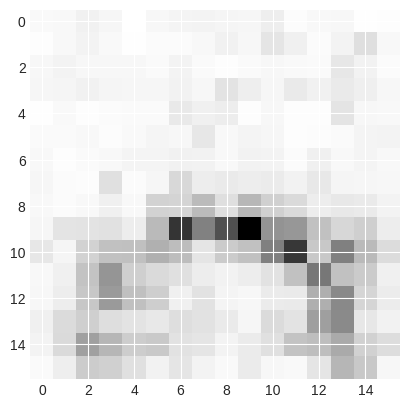

91.5 270.0


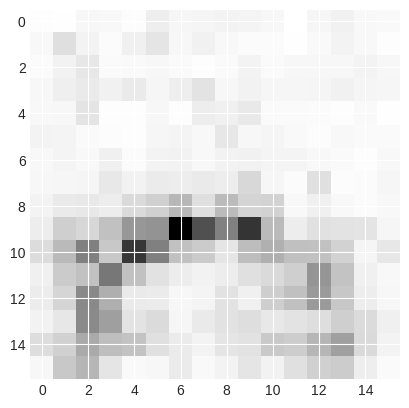

In [ ]:
CACHE_PATH = ("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/cache/"
              "care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5_combined.npz")
# ── Load cached data ──────────────────────────────────────────────────────────
d = np.load(CACHE_PATH, allow_pickle=True)
X = d["X"].astype(np.float32)              # (N, 200, 16, 16), already /150
y = d["y"].astype(np.float32)              # (N, 5): log10E, zen, az, tel_x, tel_z
target_names = list(d["target_names"])
N, T, H, W = X.shape
tel_z = d["y"][:, -1]
tel_x = d["y"][:, -2]
zen = d["y"][:, 1]
az = d["y"][:, 2]
tel_x = d["y"][:, 3]
tel_x = d["y"][:, 4]
M = d["X"]

index = (zen == 91.5)&(az == 270.0)&(tel_x==0)
M_index = M[index]
for i in range(len(zen[index])):
    print(zen[index][i], az[index][i])
    plt.imshow(np.flip(np.flip(np.sum(M_index[i], axis = 0).T, axis=0), axis=1))
    plt.show()


Imports successful
PyTorch version: 2.8.0+cu128
NumPy version: 2.0.2
Cache path: /scratch/general/vast/u1520754/cache/care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5.npz
Model path: /scratch/general/vast/u1520754/cache/care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5_combined_model_T10_mean.pt
Device:     cpu
Seed:       0

Model class defined

Loading checkpoint from /scratch/general/vast/u1520754/cache/care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5_combined_model_T10_mean.pt...

  ✓ T_original (time dim):       200
  ✓ T_downsampled (input ch):    20
  ✓ time_step (downsampling):    10
  ✓ agg_method:                  mean
  ✓ Targets:                     [np.str_('log10E'), np.str_('zen_deg'), np.str_('az_deg'), np.str_('tel_x_m'), np.str_('tel_z_m')]
  ✓ y_mean: [ 4.1489153e+00  9.0000076e+01  2.7000162e+02  6.4614704e-03
 -4.5088688e-03]
  ✓ y_std:  [0.5754708 1.0871203 1.4977185 1.9384446 1.6704967]

  ✓ Model loaded and set to eval mode

Loading data from /scratch/general/vast/u1520754/cach

/tmp/ipykernel_1404603/1301877371.py:292: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_1404603/1301877371.py:293: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  plt.savefig('residual_diagnostic.png', dpi=150, bbox_inches='tight')
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


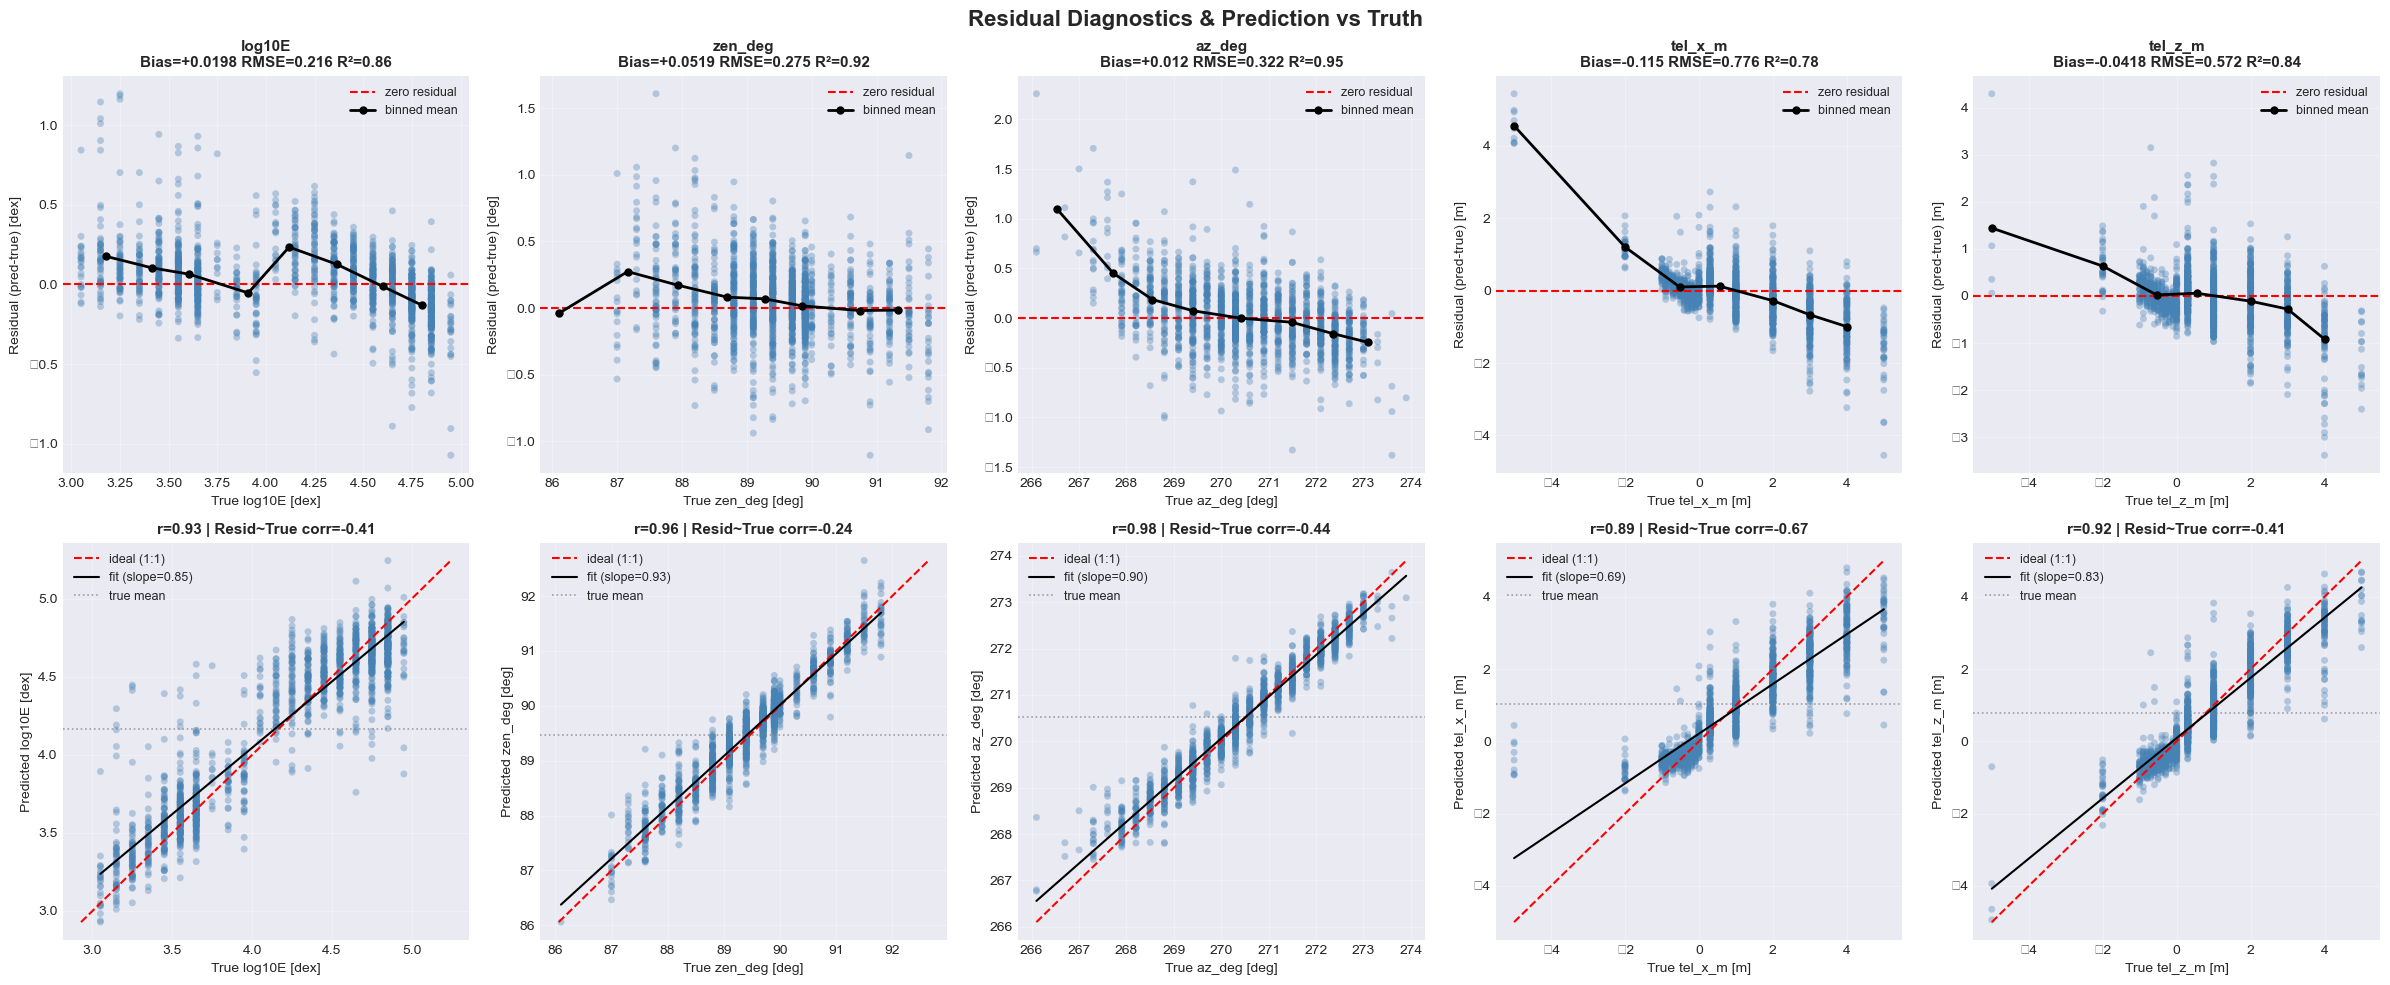

✓ Saved: residual_diagnostic.png

Computing spatial saliency maps...


/tmp/ipykernel_1404603/1301877371.py:326: UserWarning: Glyph 8706 (\N{PARTIAL DIFFERENTIAL}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_1404603/1301877371.py:327: UserWarning: Glyph 8706 (\N{PARTIAL DIFFERENTIAL}) missing from font(s) Arial.
  plt.savefig('saliency_spatial.png', dpi=150, bbox_inches='tight')
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8706 (\N{PARTIAL DIFFERENTIAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


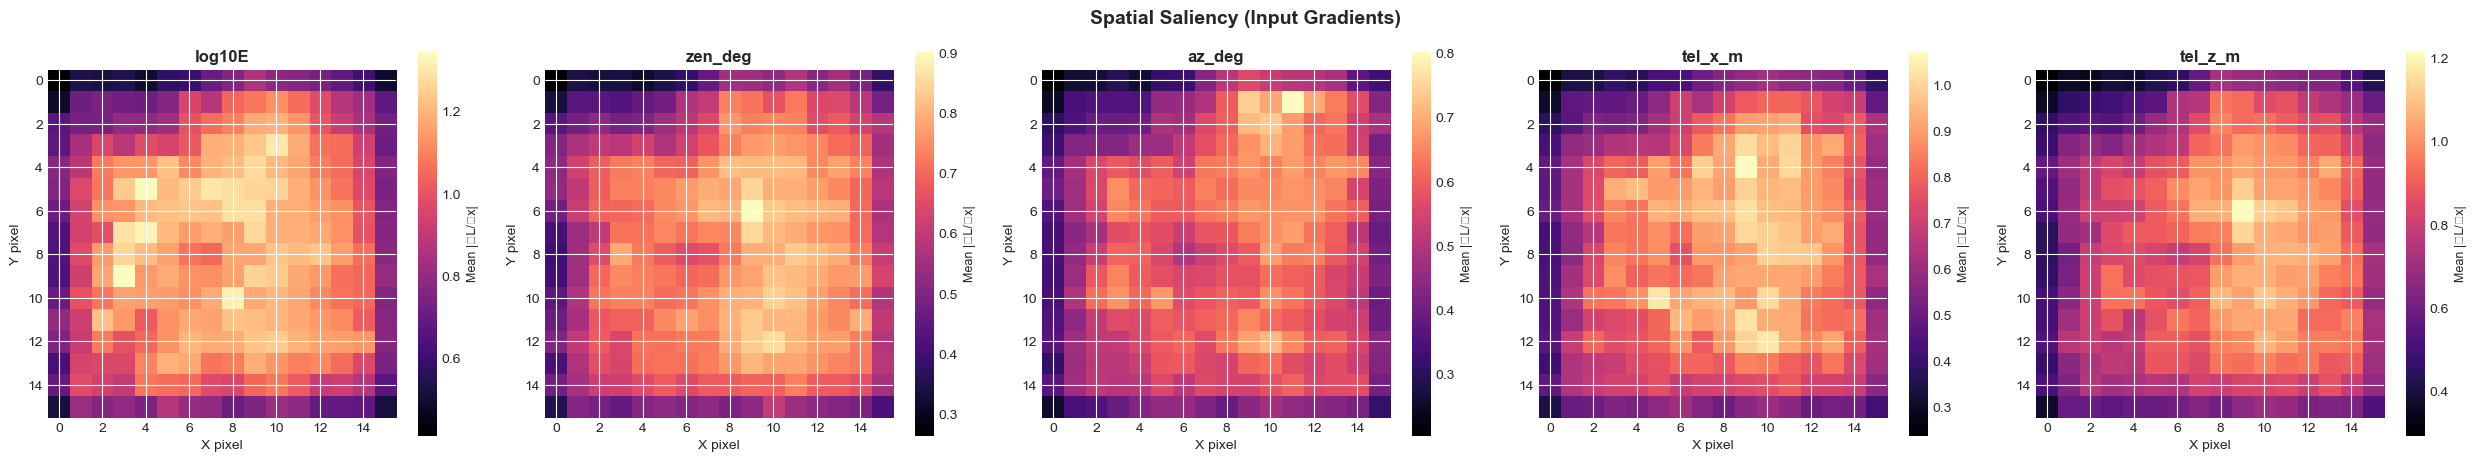

✓ Saved: saliency_spatial.png

Computing temporal saliency...


/tmp/ipykernel_1404603/1301877371.py:361: UserWarning: Glyph 8706 (\N{PARTIAL DIFFERENTIAL}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_1404603/1301877371.py:362: UserWarning: Glyph 8706 (\N{PARTIAL DIFFERENTIAL}) missing from font(s) Arial.
  plt.savefig('saliency_temporal.png', dpi=150, bbox_inches='tight')


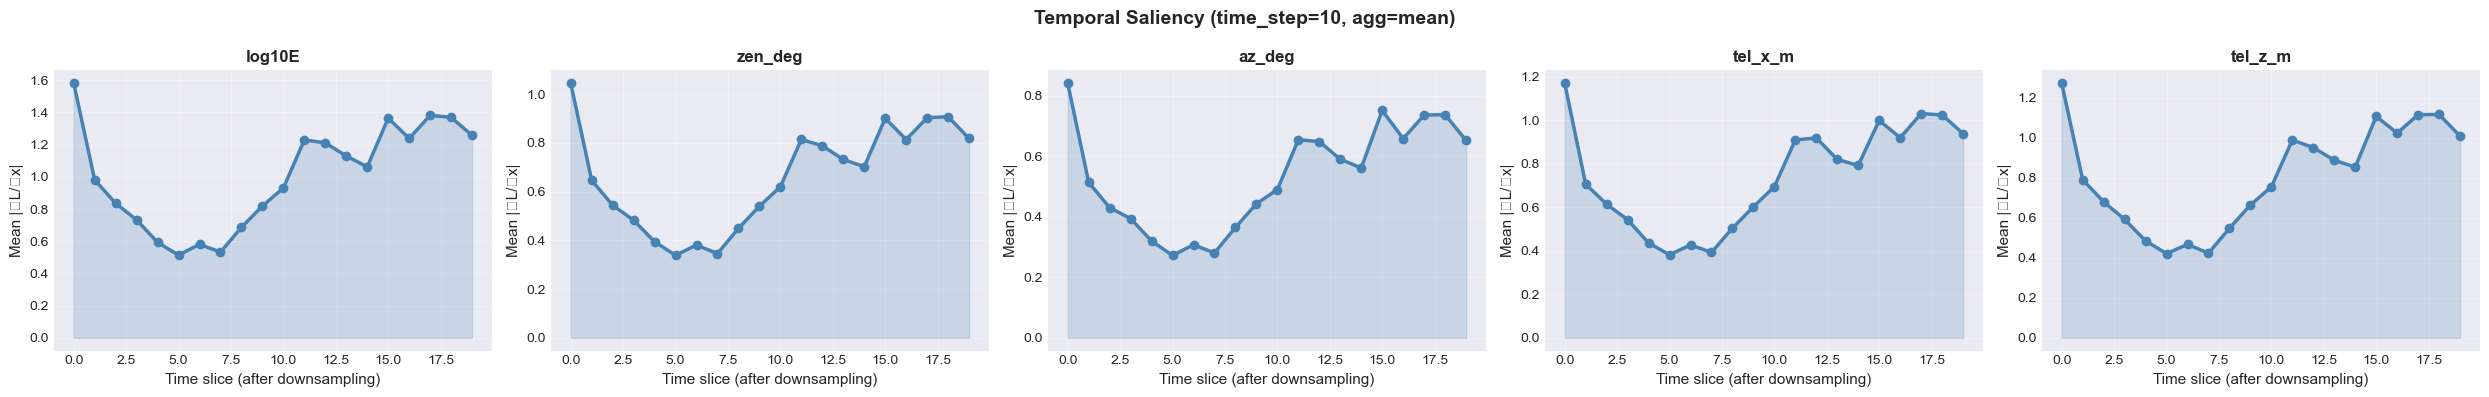

✓ Saved: saliency_temporal.png

ANALYSIS SUMMARY
Cache file:           care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5.npz
Model file:           care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5_combined_model_T10_mean.pt
Downsampling:         time_step=10, agg_method=mean
Input channels:       20 (from original T=200)
Validation size:      1677 / 8386 (20.0%)

Best performing targets (by R²):
  1. az_deg       R²=0.948 RMSE=0.3220
  2. zen_deg      R²=0.919 RMSE=0.2753
  3. log10E       R²=0.862 RMSE=0.2159

Saved outputs:
  • residual_diagnostic.png
  • saliency_spatial.png
  • saliency_temporal.png


/tmp/ipykernel_1404603/1301877371.py:397: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  plt.savefig("embedding_pca.png", dpi=150)
/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


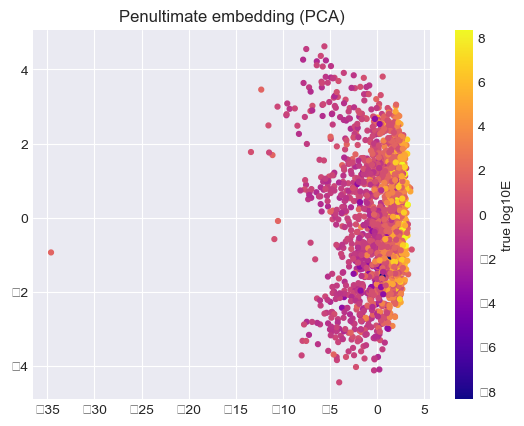

In [4]:
# ============================================================================
# VALIDATION & DIAGNOSTIC ANALYSIS NOTEBOOK
# ============================================================================
# Loads a trained model with temporal downsampling and generates diagnostics
# ============================================================================

# Cell 1: Setup and imports
# ============================================================================
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# Cell 2: Configuration
# ============================================================================
# EDIT THESE PATHS
CACHE_PATH = "/scratch/general/vast/u1520754/cache/care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5.npz"
MODEL_PATH = CACHE_PATH.replace("5.npz", "5_combined_model_T10_mean.pt")  # ← EDIT THIS
#CACHE_PATH = CACHE_PATH.replace("_flipped_Azimuth.npz", "_combined.npz")  # ← EDIT THIS
DEVICE = torch.device("cpu")
SEED = 0

print(f"Cache path: {CACHE_PATH}")
print(f"Model path: {MODEL_PATH}")
print(f"Device:     {DEVICE}")
print(f"Seed:       {SEED}\n")

torch.manual_seed(SEED)
np.random.seed(SEED)

# Cell 3: Model definition
# ============================================================================
class CareRegressor(nn.Module):
    """Convolutional regression model matching training script"""
    def __init__(self, in_ch, n_out=5, p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),    nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),   nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128, n_out),
        )
    
    def forward(self, x):
        return self.head(self.features(x))

print("Model class defined\n")

# Cell 4: Load checkpoint
# ============================================================================
print(f"Loading checkpoint from {MODEL_PATH}...\n")
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)

# Extract training parameters
T_downsampled = ckpt["T_downsampled"]  # Number of input channels to model
T_original    = ckpt["T_original"]     # Original time dimension
time_step     = ckpt["time_step"]      # Downsampling factor
agg_method    = ckpt["agg_method"]     # Aggregation method

y_mean        = ckpt["y_mean"].to(DEVICE)
y_std         = ckpt["y_std"].to(DEVICE)
target_names  = list(ckpt["target_names"])

print(f"  ✓ T_original (time dim):       {T_original}")
print(f"  ✓ T_downsampled (input ch):    {T_downsampled}")
print(f"  ✓ time_step (downsampling):    {time_step}")
print(f"  ✓ agg_method:                  {agg_method}")
print(f"  ✓ Targets:                     {target_names}")
print(f"  ✓ y_mean: {y_mean.cpu().numpy()}")
print(f"  ✓ y_std:  {y_std.cpu().numpy()}\n")

# Load model weights
model = CareRegressor(in_ch=T_downsampled, n_out=len(target_names)).to(DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()

def destd(yb):
    """Denormalize predictions"""
    return yb * y_std + y_mean

print(f"  ✓ Model loaded and set to eval mode\n")

# Cell 5: Load and downsample data
# ============================================================================
print(f"Loading data from {CACHE_PATH}...")
d = np.load(CACHE_PATH, allow_pickle=True)
X_orig = d["X"].astype(np.float32)  # (N, 200, 16, 16)
y = d["y"].astype(np.float32)        # (N, 5)

print(f"  Original X shape: {X_orig.shape}")
print(f"  y shape:          {y.shape}\n")

# Downsample time dimension to match training
def downsample_time(X_orig, time_step, agg_method="max"):
    """
    Downsample X along time axis by selecting representative frames.
    
    For each window of size `time_step`, compute total PE per spatial location,
    then select/aggregate according to agg_method.
    
    Args:
        X_orig: (N, T, 16, 16) array
        time_step: window size (e.g., 2 or 4)
        agg_method: "max" | "mean" | "median"
    
    Returns:
        X_ds: (N, T_new, 16, 16) downsampled array
        T_new: new time dimension
    """
    N, T, H, W = X_orig.shape
    if time_step == 1:
        return X_orig.copy(), T
    
    # Pad T to be divisible by time_step
    T_pad = ((T + time_step - 1) // time_step) * time_step
    X_padded = np.pad(X_orig, ((0, 0), (0, T_pad - T), (0, 0), (0, 0)), 
                      mode='constant', constant_values=0)

    # Reshape into windows: (N, T_new, time_step, H, W)
    T_new = T_pad // time_step
    X_windowed = X_padded.reshape(N, T_new, time_step, H, W)

    if agg_method == "max":
        # For each window, find the frame with max total PE, select that frame
        total_pe = X_windowed.sum(axis=(3, 4))  # (N, T_new, time_step)
        max_idx = np.argmax(total_pe, axis=2)   # (N, T_new) indices
        X_ds = X_windowed[np.arange(N)[:, None], 
                          np.arange(T_new)[None, :], 
                          max_idx]  # (N, T_new, H, W)

    elif agg_method == "mean":
        # Average all frames in each window
        X_ds = X_windowed.mean(axis=2)  # (N, T_new, H, W)

    elif agg_method == "median":
        # Median of all frames in each window
        X_ds = np.median(X_windowed, axis=2)  # (N, T_new, H, W)

    else:
        raise ValueError(f"Unknown agg_method: {agg_method}")

    return X_ds.astype(np.float32), T_new

X_ds, T_new = downsample_time(X_orig, time_step, agg_method)
print(f"Downsampled X shape: {X_ds.shape} (time: {T_original} -> {T_new})")

# Validation checks
assert X_ds.shape[1] == T_downsampled, f"Downsampled X time {X_ds.shape[1]} != model T {T_downsampled}"
assert X_ds.shape[2:] == (16, 16), f"X spatial {X_ds.shape[2:]} != (16, 16)"
assert y.shape[1] == len(target_names), f"y targets {y.shape[1]} != {len(target_names)}"

print(f"  ✓ All shape validations passed\n")

# Cell 6: Create validation split
# ============================================================================
X_t = torch.from_numpy(X_ds)
y_t = torch.from_numpy(y)
N = X_ds.shape[0]
n_val = max(1, int(0.2 * N))
n_train = N - n_val

print(f"Data split (seed={SEED}):")
print(f"  Total:  {N}")
print(f"  Train:  {n_train}")
print(f"  Val:    {n_val}\n")

_, val_ds = random_split(
    TensorDataset(X_t, y_t), 
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"  ✓ Validation dataset created with {len(val_ds)} samples\n")

# Cell 7: Run predictions
# ============================================================================
print(f"Running predictions on validation set...")
with torch.no_grad():
    xb, yb = next(iter(DataLoader(val_ds, batch_size=len(val_ds))))
    pred = destd(model(xb.to(DEVICE))).cpu().numpy()
    true = yb.numpy()

resid = pred - true

print(f"  ✓ Predictions shape: {pred.shape}")
print(f"  ✓ Residuals shape:   {resid.shape}\n")

# Cell 8: Compute statistics
# ============================================================================
units = ["dex", "deg", "deg", "m", "m"]

stats_list = []
print("="*100)
print("RESIDUAL & PREDICTION STATISTICS")
print("="*100)
print(f"{'Target':12s} {'Bias':>10s} {'RMSE':>10s} {'R²':>8s} {'Slope':>8s} {'Corr':>8s} {'Resid-True':>12s}")
print("-"*100)

for i, (name, u) in enumerate(zip(target_names, units)):
    t, p, r = true[:, i], pred[:, i], resid[:, i]
    
    rmse       = np.sqrt(np.mean(r**2))
    bias       = np.mean(r)
    std_true   = t.std()
    std_resid  = r.std()
    slope      = np.polyfit(t, p, 1)[0] if std_true > 1e-9 else np.nan
    corr       = np.corrcoef(t, p)[0, 1] if std_true > 1e-9 and p.std() > 1e-9 else np.nan
    r2         = 1 - np.sum(r**2) / np.sum((t - t.mean())**2) if std_true > 1e-9 else np.nan
    resid_corr = np.corrcoef(t, r)[0, 1] if std_true > 1e-9 and std_resid > 1e-9 else np.nan
    
    stats_list.append({
        'target': name,
        'bias': bias,
        'rmse': rmse,
        'r2': r2,
        'slope': slope,
        'corr': corr,
        'resid_corr': resid_corr,
        'std_true': std_true,
        'std_resid': std_resid
    })
    
    print(f"{name:12s} {bias:+10.4f} {rmse:10.4f} {r2:8.3f} {slope:8.3f} {corr:8.3f} {resid_corr:+12.3f}")

print("="*100 + "\n")

# Cell 9: Plot 1 - Residual diagnostics & prediction vs truth
# ============================================================================
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle("Residual Diagnostics & Prediction vs Truth", fontsize=16, fontweight='bold')

for i, (name, u) in enumerate(zip(target_names, units)):
    t, p, r = true[:, i], pred[:, i], resid[:, i]
    stats = stats_list[i]
    
    # ---- Top row: Residual vs True ----
    ax = axes[0, i]
    ax.scatter(t, r, s=25, alpha=0.35, edgecolor="none", color='steelblue')
    ax.axhline(0.0, color='red', ls='--', lw=1.5, label='zero residual')
    
    # Binned mean residual
    bins = np.linspace(t.min(), t.max(), 9)
    idx  = np.digitize(t, bins)
    bx = [t[idx == b].mean() for b in range(1, len(bins)) if np.any(idx == b)]
    by = [r[idx == b].mean() for b in range(1, len(bins)) if np.any(idx == b)]
    ax.plot(bx, by, 'k-o', lw=2, ms=5, label='binned mean', zorder=5)
    
    ax.set_xlabel(f'True {name} [{u}]', fontsize=10)
    ax.set_ylabel(f'Residual (pred-true) [{u}]', fontsize=10)
    ax.set_title(f'{name}\nBias={stats["bias"]:+.3g} RMSE={stats["rmse"]:.3g} R²={stats["r2"]:.2f}', 
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    
    # ---- Bottom row: Pred vs True ----
    ax2 = axes[1, i]
    ax2.scatter(t, p, s=25, alpha=0.35, edgecolor="none", color='steelblue')
    
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    ax2.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='ideal (1:1)', zorder=4)
    
    xx = np.linspace(t.min(), t.max(), 100)
    if not np.isnan(stats['slope']):
        b0 = np.polyfit(t, p, 1)[1]
        ax2.plot(xx, stats['slope'] * xx + b0, 'k-', lw=1.5, 
                label=f'fit (slope={stats["slope"]:.2f})', zorder=4)
    
    ax2.axhline(t.mean(), color='gray', ls=':', lw=1.2, alpha=0.7, label='true mean')
    ax2.set_xlabel(f'True {name} [{u}]', fontsize=10)
    ax2.set_ylabel(f'Predicted {name} [{u}]', fontsize=10)
    ax2.set_title(f'r={stats["corr"]:.2f} | Resid~True corr={stats["resid_corr"]:+.2f}', 
                  fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9, loc='best')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: residual_diagnostic.png\n")

# Cell 10: Plot 2 - Spatial saliency maps
# ============================================================================
print("Computing spatial saliency maps...")

fig, axes = plt.subplots(1, len(target_names), figsize=(5*len(target_names), 4.5))
if len(target_names) == 1:
    axes = [axes]

fig.suptitle("Spatial Saliency (Input Gradients)", fontsize=14, fontweight='bold')

for target_idx, (ax, name) in enumerate(zip(axes, target_names)):
    xb, yb = next(iter(DataLoader(val_ds, batch_size=len(val_ds))))
    xb = xb.to(DEVICE).requires_grad_(True)
    
    pred = model(xb)
    score = pred[:, target_idx].sum()
    score.backward()
    
    sal = xb.grad.abs().detach().cpu().numpy()
    sal_spatial = sal.mean(axis=(0, 1))  # Average over batch and time channels
    
    im = ax.imshow(sal_spatial, cmap='magma', interpolation='nearest')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean |∂L/∂x|', fontsize=9)

plt.tight_layout()
plt.savefig('saliency_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: saliency_spatial.png\n")

# Cell 11: Plot 3 - Temporal saliency
# ============================================================================
print("Computing temporal saliency...")

fig, axes = plt.subplots(1, len(target_names), figsize=(5*len(target_names), 4))
if len(target_names) == 1:
    axes = [axes]

fig.suptitle(f"Temporal Saliency (time_step={time_step}, agg={agg_method})", 
             fontsize=14, fontweight='bold')

for target_idx, (ax, name) in enumerate(zip(axes, target_names)):
    xb, yb = next(iter(DataLoader(val_ds, batch_size=len(val_ds))))
    xb = xb.to(DEVICE).requires_grad_(True)
    
    pred = model(xb)
    score = pred[:, target_idx].sum()
    score.backward()
    
    sal = xb.grad.abs().detach().cpu().numpy()
    sal_temporal = sal.mean(axis=(0, 2, 3))  # Average over batch and spatial
    
    ax.plot(sal_temporal, linewidth=2.5, marker='o', markersize=6, color='steelblue')
    ax.fill_between(range(len(sal_temporal)), sal_temporal, alpha=0.2, color='steelblue')
    ax.set_xlabel('Time slice (after downsampling)', fontsize=11)
    ax.set_ylabel('Mean |∂L/∂x|', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('saliency_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: saliency_temporal.png\n")

# Cell 12: Summary
# ============================================================================
print("="*100)
print("ANALYSIS SUMMARY")
print("="*100)
print(f"Cache file:           {Path(CACHE_PATH).name}")
print(f"Model file:           {Path(MODEL_PATH).name}")
print(f"Downsampling:         time_step={time_step}, agg_method={agg_method}")
print(f"Input channels:       {T_downsampled} (from original T={T_original})")
print(f"Validation size:      {n_val} / {N} ({100*n_val/N:.1f}%)")
print(f"\nBest performing targets (by R²):")
sorted_stats = sorted(stats_list, key=lambda x: x['r2'], reverse=True)
for i, s in enumerate(sorted_stats[:3], 1):
    print(f"  {i}. {s['target']:12s} R²={s['r2']:.3f} RMSE={s['rmse']:.4f}")
print(f"\nSaved outputs:")
print(f"  • residual_diagnostic.png")
print(f"  • saliency_spatial.png")
print(f"  • saliency_temporal.png")
print("="*100)
feat = {}
model.head[1].register_forward_hook(lambda m,i,o: feat.__setitem__("z", o.detach().cpu()))
with torch.no_grad(): model(xb)
Z = feat["z"].numpy()             # (N, 128)
device = torch.device("cpu")

from sklearn.decomposition import PCA
Z2 = PCA(n_components=2).fit_transform(Z)
true_E = destd(yb.to(device)).cpu().numpy()[:, target_idx]
plt.scatter(Z2[:,0], Z2[:,1], c=true_E, cmap="plasma", s=12)
plt.colorbar(label="true log10E"); plt.title("Penultimate embedding (PCA)")
plt.savefig("embedding_pca.png", dpi=150)

In [5]:
#Load Real Data
import numpy as np

pixel_config = [ #I need to regenerate it again in the future
        # Pixel ID, x, y (In mm, extracted from your input data)
        (0, -46.875, -46.875), (1, -46.875, -40.625), 
        (2, -46.875, -34.375), (3, -46.875, -28.125),
        (4, -40.625, -46.875), (5, -40.625, -40.625), 
        (6, -40.625, -34.375), (7, -40.625, -28.125),
        (8, -34.375, -46.875), (9, -34.375, -40.625),
        (10, -34.375, -34.375), (11, -34.375, -28.125),
        (12, -28.125, -46.875), (13, -28.125, -40.625),
        (14, -28.125, -34.375), (15, -28.125, -28.125),
        (16, -21.875, -46.875), (17, -21.875, -40.625),
        (18, -21.875, -34.375), (19, -21.875, -28.125),
        (20, -15.625, -46.875), (21, -15.625, -40.625),
        (22, -15.625, -34.375), (23, -15.625, -28.125),
        (24, -9.375, -46.875), (25, -9.375, -40.625),
        (26, -9.375, -34.375), (27, -9.375, -28.125),
        (28, -3.125, -46.875), (29, -3.125, -40.625),
        (30, -3.125, -34.375), (31, -3.125, -28.125),
        (32, 3.125, -46.875), (33, 3.125, -40.625),
        (34, 3.125, -34.375), (35, 3.125, -28.125),
        (36, 9.375, -46.875), (37, 9.375, -40.625),
        (38, 9.375, -34.375), (39, 9.375, -28.125),
        (40, 15.625, -46.875), (41, 15.625, -40.625),
        (42, 15.625, -34.375), (43, 15.625, -28.125),
        (44, 21.875, -46.875), (45, 21.875, -40.625),
        (46, 21.875, -34.375), (47, 21.875, -28.125),
        (48, 28.125, -46.875), (49, 28.125, -40.625),
        (50, 28.125, -34.375), (51, 28.125, -28.125),
        (52, 34.375, -46.875), (53, 34.375, -40.625),
        (54, 34.375, -34.375), (55, 34.375, -28.125),
        (56, 40.625, -46.875), (57, 40.625, -40.625),
        (58, 40.625, -34.375), (59, 40.625, -28.125),
        (60, 46.875, -46.875), (61, 46.875, -40.625),
        (62, 46.875, -34.375), (63, 46.875, -28.125),
        (64, -46.875, -21.875), (65, -46.875, -15.625),
        (66, -46.875, -9.375), (67, -46.875, -3.125),
        (68, -40.625, -21.875), (69, -40.625, -15.625),
        (70, -40.625, -9.375), (71, -40.625, -3.125),
        (72, -34.375, -21.875), (73, -34.375, -15.625),
        (74, -34.375, -9.375), (75, -34.375, -3.125),
        (76, -28.125, -21.875), (77, -28.125, -15.625),
        (78, -28.125, -9.375), (79, -28.125, -3.125),
        (80, -21.875, -21.875), (81, -21.875, -15.625),
        (82, -21.875, -9.375), (83, -21.875, -3.125),
        (84, -15.625, -21.875), (85, -15.625, -15.625),
        (86, -15.625, -9.375), (87, -15.625, -3.125),
        (88, -9.375, -21.875), (89, -9.375, -15.625),
        (90, -9.375, -9.375), (91, -9.375, -3.125),
        (92, -3.125, -21.875), (93, -3.125, -15.625),
        (94, -3.125, -9.375), (95, -3.125, -3.125),
        (96, 3.125, -21.875), (97, 3.125, -15.625),
        (98, 3.125, -9.375), (99, 3.125, -3.125),
        (100, 9.375, -21.875), (101, 9.375, -15.625),
        (102, 9.375, -9.375), (103, 9.375, -3.125),
        (104, 15.625, -21.875), (105, 15.625, -15.625),
        (106, 15.625, -9.375), (107, 15.625, -3.125),
        (108, 21.875, -21.875), (109, 21.875, -15.625),
        (110, 21.875, -9.375), (111, 21.875, -3.125),
        (112, 28.125, -21.875), (113, 28.125, -15.625),
        (114, 28.125, -9.375), (115, 28.125, -3.125),
        (116, 34.375, -21.875), (117, 34.375, -15.625),
        (118, 34.375, -9.375), (119, 34.375, -3.125),
        (120, 40.625, -21.875), (121, 40.625, -15.625),
        (122, 40.625, -9.375), (123, 40.625, -3.125),
        (124, 46.875, -21.875), (125, 46.875, -15.625),
        (126, 46.875, -9.375), (127, 46.875, -3.125),
        (128, -46.875, 3.125), (129, -46.875, 9.375),
        (130, -46.875, 15.625), (131, -46.875, 21.875),
        (132, -40.625, 3.125), (133, -40.625, 9.375),
        (134, -40.625, 15.625), (135, -40.625, 21.875),
        (136, -34.375, 3.125), (137, -34.375, 9.375),
        (138, -34.375, 15.625), (139, -34.375, 21.875),
        (140, -28.125, 3.125), (141, -28.125, 9.375),
        (142, -28.125, 15.625), (143, -28.125, 21.875),
        (144, -21.875, 3.125), (145, -21.875, 9.375),
        (146, -21.875, 15.625), (147, -21.875, 21.875),
        (148, -15.625, 3.125), (149, -15.625, 9.375),
        (150, -15.625, 15.625), (151, -15.625, 21.875),
        (152, -9.375, 3.125), (153, -9.375, 9.375),
        (154, -9.375, 15.625), (155, -9.375, 21.875),
        (156, -3.125, 3.125), (157, -3.125, 9.375),
        (158, -3.125, 15.625), (159, -3.125, 21.875),
        (160, 3.125, 3.125), (161, 3.125, 9.375),
        (162, 3.125, 15.625), (163, 3.125, 21.875),
        (164, 9.375, 3.125), (165, 9.375, 9.375),
        (166, 9.375, 15.625), (167, 9.375, 21.875),
        (168, 15.625, 3.125), (169, 15.625, 9.375),
        (170, 15.625, 15.625), (171, 15.625, 21.875),
        (172, 21.875, 3.125), (173, 21.875, 9.375),
        (174, 21.875, 15.625), (175, 21.875, 21.875),
        (176, 28.125, 3.125), (177, 28.125, 9.375),
        (178, 28.125, 15.625), (179, 28.125, 21.875),
        (180, 34.375, 3.125), (181, 34.375, 9.375),
        (182, 34.375, 15.625), (183, 34.375, 21.875),
        (184, 40.625, 3.125), (185, 40.625, 9.375),
        (186, 40.625, 15.625), (187, 40.625, 21.875),
        (188, 46.875, 3.125), (189, 46.875, 9.375),
        (190, 46.875, 15.625), (191, 46.875, 21.875),
        (192, -46.875, 28.125), (193, -46.875, 34.375),
        (194, -46.875, 40.625), (195, -46.875, 46.875),
        (196, -40.625, 28.125), (197, -40.625, 34.375),
        (198, -40.625, 40.625), (199, -40.625, 46.875),
        (200, -34.375, 28.125), (201, -34.375, 34.375),
        (202, -34.375, 40.625), (203, -34.375, 46.875),
        (204, -28.125, 28.125), (205, -28.125, 34.375),
        (206, -28.125, 40.625), (207, -28.125, 46.875),
        (208, -21.875, 28.125), (209, -21.875, 34.375),
        (210, -21.875, 40.625), (211, -21.875, 46.875),
        (212, -15.625, 28.125), (213, -15.625, 34.375),
        (214, -15.625, 40.625), (215, -15.625, 46.875),
        (216, -9.375, 28.125), (217, -9.375, 34.375),
        (218, -9.375, 40.625), (219, -9.375, 46.875),
        (220, -3.125, 28.125), (221, -3.125, 34.375),
        (222, -3.125, 40.625), (223, -3.125, 46.875),
        (224, 3.125, 28.125), (225, 3.125, 34.375),
        (226, 3.125, 40.625), (227, 3.125, 46.875),
        (228, 9.375, 28.125), (229, 9.375, 34.375),
        (230, 9.375, 40.625), (231, 9.375, 46.875),
        (232, 15.625, 28.125), (233, 15.625, 34.375),
        (234, 15.625, 40.625), (235, 15.625, 46.875),
        (236, 21.875, 28.125), (237, 21.875, 34.375),
        (238, 21.875, 40.625), (239, 21.875, 46.875),
        (240, 28.125, 28.125), (241, 28.125, 34.375),
        (242, 28.125, 40.625), (243, 28.125, 46.875),
        (244, 34.375, 28.125), (245, 34.375, 34.375),
        (246, 34.375, 40.625), (247, 34.375, 46.875),
        (248, 40.625, 28.125), (249, 40.625, 34.375),
        (250, 40.625, 40.625), (251, 40.625, 46.875),
        (252, 46.875, 28.125), (253, 46.875, 34.375),
        (254, 46.875, 40.625), (255, 46.875, 46.875)
    ]
def build_pixel_map(pixel_config, pixel_pitch=6.25):
    xs = [p[1] for p in pixel_config]
    ys = [p[2] for p in pixel_config]
    min_x, min_y = min(xs), min(ys)
    max_x, max_y = max(xs), max(ys)
    ncol = int((max_x - min_x) / pixel_pitch) + 1
    nrow = int((max_y - min_y) / pixel_pitch) + 1

    pixel_map = {}
    for pid, x, y in pixel_config:
        col = int(round((x - min_x) / pixel_pitch))
        row = int(round((y - min_y) / pixel_pitch))
        pixel_map[pid] = (row, col)
    return pixel_map, (nrow, ncol), (min_x, max_x, min_y, max_y)

def to_camera_image(values, pixel_map, shape):
    """values: 1D array indexed by pixel ID."""
    img = np.full(shape, np.nan)   # NaN for missing pixels -> shows as blank
    for pid, v in enumerate(values):
        if pid in pixel_map:
            r, c = pixel_map[pid]
            img[r, c] = v
    return img
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
file = "/scratch/general/vast/u1520754/Data/KT20260706/Merged_CoBo0_AsAd0_2024-11-30T063728.651_0000.root"

def process_one_event(sig0, pedestal=300.0, ADC2PE=24.1,
                      pixel_map=None, shape=None):
    """sig0: (npix, nsamp) float array -> (200, nrow, ncol) or None if too short."""
    PE = np.clip(((np.max(sig0) - sig0) - pedestal) / ADC2PE, 0, None)
    PE_T = PE.T                                   # (nsamp, npix)

    hits = np.where(PE_T >= 20)[0]
    if len(hits) == 0:
        return None                               # no pixel over threshold
    index_17 = min(hits) - 17
    if index_17 < 0:
        index_17 = 0                              # guard against negative start
    PE_T = PE_T[index_17:index_17 + 200]
    if PE_T.shape[0] < 200:
        return None                               # not enough samples; skip

    Imag_time = []
    for pe_t in PE_T:
        img = to_camera_image(pe_t, pixel_map, shape)
        img = np.clip(img, None, 150)
        Imag_time.append(img / 150)
    return np.array(Imag_time)                     # (200, nrow, ncol)


def extract_data(file):
    f = uproot.open(file)
    t = f["Test"]

    # how many entries (events) are in this file?
    branch = t["Events/Event/signalValue"]
    n_entries = branch.num_entries
    print(f"  {n_entries} entries in {file.split('/')[-1]}")

    pixel_map, shape, extent = build_pixel_map(pixel_config)

    # read ALL entries at once (jagged: events × pixels × samples)
    sig = branch.array(library="ak")               # len == n_entries

    event_cubes = []
    for i in range(n_entries):
        sig0 = ak.to_numpy(sig[i]).astype(float)   # (npix, nsamp)
        cube = process_one_event(sig0, pixel_map=pixel_map, shape=shape)
        if cube is not None:
            event_cubes.append(cube)
        else:
            print(f"    entry {i}: skipped (no hit / too short)")

    f.close()
    return event_cubes                             # list of (200, nrow, ncol)
import glob, os

data_dir = "/scratch/general/vast/u1520754/Data/KT20260706"
root_files = sorted(glob.glob(os.path.join(data_dir, "*.root")))
print(f"Found {len(root_files)} files")

data_event = []
for path in root_files:
    cubes = extract_data(path)                     # list of cubes
    data_event.extend(cubes)                       # flatten across files

data_event = np.array(data_event)                  # (N_total_events, 200, nrow, ncol)
print("Final shape:", data_event.shape)


Found 20 files
  32 entries in Merged_CoBo0_AsAd0_2024-11-30T063728.651_0000.root
  113 entries in Merged_CoBo0_AsAd0_2024-11-30T111528.624_0000.root


    entry 18: skipped (no hit / too short)
    entry 30: skipped (no hit / too short)
    entry 51: skipped (no hit / too short)
  39 entries in Merged_CoBo0_AsAd0_2024-12-22T053435.338_0000.root
  32 entries in Merged_CoBo0_AsAd0_2024-12-28T032916.082_0000.root
  50 entries in Merged_CoBo0_AsAd0_2024-12-28T124915.749_0000.root
  56 entries in Merged_CoBo0_AsAd0_2025-01-06T100444.757_0000.root
  42 entries in Merged_CoBo0_AsAd0_2025-01-25T043237.311_0000.root
  64 entries in Merged_CoBo0_AsAd0_2025-01-30T101241.540_0000.root
    entry 22: skipped (no hit / too short)
    entry 25: skipped (no hit / too short)
    entry 30: skipped (no hit / too short)
    entry 39: skipped (no hit / too short)
    entry 52: skipped (no hit / too short)
  46 entries in Merged_CoBo0_AsAd0_2025-02-24T104828.207_0000.root
  45 entries in Merged_CoBo0_AsAd0_2025-02-24T114228.203_0000.root
  41 entries in Merged_CoBo0_AsAd0_2025-03-01T081920.813_0000.root
    entry 20: skipped (no hit / too

In [ ]:
np.shape(data_event), np.shape(X_real)

((836, 200, 16, 16), (836, 20, 16, 16))

Real X after downsample: (836, 20, 16, 16)

 Event     log10E    zen_deg     az_deg    tel_x_m    tel_z_m
----------------------------------------------------------------------
     0      4.382     89.951    270.708      1.025      2.124
     1      4.740     89.988    270.545      0.417      0.687
     2      4.994     90.395    270.503     -0.191      4.227
     3      4.806     89.256    270.054      0.369      1.224
     4      4.858     89.920    270.480      2.254      2.789
     5      4.808     89.790    270.517      0.556      2.240
     6      4.673     90.098    270.868      0.733      2.095
     7      4.734     89.506    270.819      1.457      0.788
     8      4.163     89.624    269.646     -1.026      0.505
     9      4.913     90.165    270.964      3.731      1.075
    10      5.029     90.430    271.002      1.055      2.445
    11      4.804     89.647    270.276      0.457      1.884
    12      4.811     89.629    270.824      1.053      0.751
    13      4.852

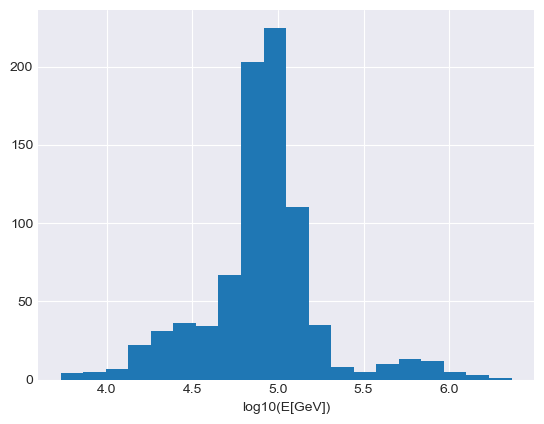

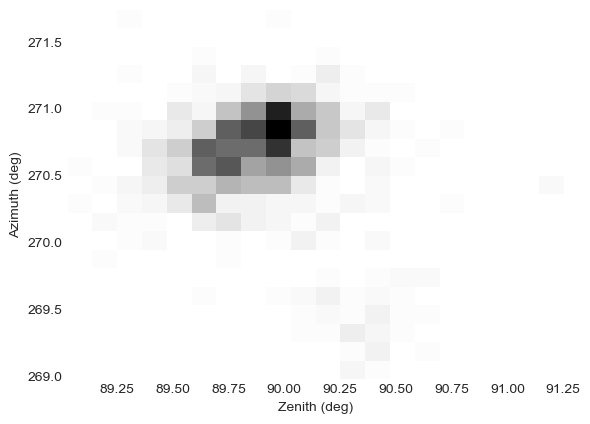

/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


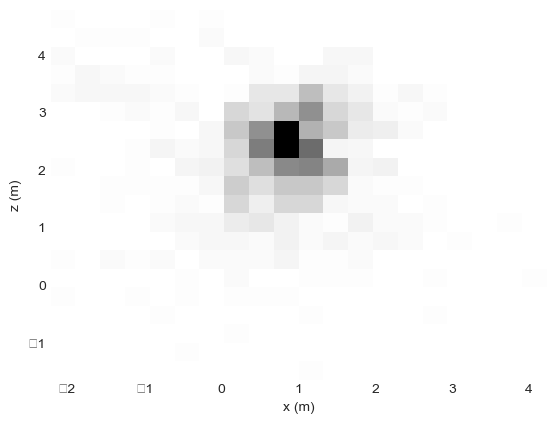

In [6]:
# ---- 1. Match the model's temporal downsampling ----
# Model expects T_downsampled=20 channels, time_step=1, agg_method='mean'
X_real, T_new = downsample_time(
    data_event.astype(np.float32),   # (20, 200, 16, 16)
    time_step,                        # 10  (from checkpoint)
    agg_method                        # 'mean' (from checkpoint)
)
print("Real X after downsample:", X_real.shape)   # -> (20, 20, 16, 16)

assert X_real.shape[1] == T_downsampled, \
    f"{X_real.shape[1]} != model input channels {T_downsampled}"

# ---- 2. Run the model ----
X_real_t = torch.from_numpy(X_real).to(DEVICE)

model.eval()
with torch.no_grad():
    pred_real = destd(model(X_real_t)).cpu().numpy()   # (20, 5)

# ---- 3. Show predictions ----
print(f"\n{'Event':>6s} " + " ".join(f"{n:>10s}" for n in target_names))
print("-" * 70)
for i, row in enumerate(pred_real):
    print(f"{i:6d} " + " ".join(f"{v:10.3f}" for v in row))

# Summary stats across the 20 events
print("\nMean prediction:", pred_real.mean(axis=0))
print("Std  prediction:", pred_real.std(axis=0))

E_recon = pred_real[:,0]
zen_recon = pred_real[:,1]
az_recon = pred_real[:,2]
x_recon = pred_real[:,3]
z_recon = pred_real[:,4]

plt.hist(E_recon, bins=20)
plt.xlabel("log10(E[GeV])")
plt.show()

plt.hist2d(zen_recon, az_recon, bins =20)
plt.xlabel("Zenith (deg)")
plt.ylabel("Azimuth (deg)")
plt.show()

plt.hist2d(x_recon, z_recon, bins =20)
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.show()



In [7]:
# ---- 0. Load the simulated dataset (images + true labels) ----
def downsample_time(X_orig, time_step, agg_method="max"):
    """
    Downsample X along time axis by selecting representative frames.
    
    For each window of size `time_step`, compute total PE per spatial location,
    then select/aggregate according to agg_method.
    
    Args:
        X_orig: (N, T, 16, 16) array
        time_step: window size (e.g., 2 or 4)
        agg_method: "max" | "mean" | "median"
    
    Returns:
        X_ds: (N, T_new, 16, 16) downsampled array
        T_new: new time dimension
    """
    N, T, H, W = X_orig.shape
    if time_step == 1:
        return X_orig.copy(), T
    else:
        # Pad T to be divisible by time_step
        T_pad = ((T + time_step - 1) // time_step) * time_step
        X_padded = np.pad(X_orig, ((0, 0), (0, T_pad - T), (0, 0), (0, 0)), 
                        mode='constant', constant_values=0)

        # Reshape into windows: (N, T_new, time_step, H, W)
        T_new = T_pad // time_step
        X_windowed = X_padded.reshape(N, T_new, time_step, H, W)

        if agg_method == "max":
            # For each window, find the frame with max total PE, select that frame
            total_pe = X_windowed.sum(axis=(3, 4))  # (N, T_new, time_step)
            max_idx = np.argmax(total_pe, axis=2)   # (N, T_new) indices
            X_ds = X_windowed[np.arange(N)[:, None], 
                            np.arange(T_new)[None, :], 
                            max_idx]  # (N, T_new, H, W)

        elif agg_method == "mean":
            # Average all frames in each window
            X_ds = X_windowed.mean(axis=2)  # (N, T_new, H, W)

        elif agg_method == "median":
            # Median of all frames in each window
            X_ds = np.median(X_windowed, axis=2)  # (N, T_new, H, W)

        else:
            raise ValueError(f"Unknown agg_method: {agg_method}")

        return X_ds.astype(np.float32), T_new
sim = np.load(
    "/scratch/general/vast/u1520754/"
    "cache/care_cube_pid13_E1e+03-1e+05_R5_thr20_sz0.5.npz",
    allow_pickle=True)
print(sim.files)   # inspect keys!

X_sim_raw = sim["X"].astype(np.float32)     # (Nsim, 200, 16, 16)  <-- adjust key
y_sim     = sim["y"].astype(np.float32)     # (Nsim, 5) true params <-- adjust key

# ---- 1. Downsample sim the SAME way as real ----
X_sim, _ = downsample_time(X_sim_raw,time_step, agg_method)   # (Nsim, 20,16,16)

# ---- 2. Hook the penultimate layer to grab embeddings ----
feat = {}
h = model.head[1].register_forward_hook(
        lambda m, i, o: feat.__setitem__("z", o.detach().cpu().numpy()))

def get_embeddings(X):
    embs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X), 256):                     # batch to save memory
            xb = torch.from_numpy(X[i:i+256]).to(DEVICE)
            model(xb)
            embs.append(feat["z"].copy())
    return np.concatenate(embs, axis=0)

Z_real = get_embeddings(X_real)     # (20,  128)
Z_sim  = get_embeddings(X_sim)      # (Nsim,128)
h.remove()

# ---- 3. Standardize features, then nearest neighbor ----
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

scaler = StandardScaler().fit(Z_sim)
Z_sim_s, Z_real_s = scaler.transform(Z_sim), scaler.transform(Z_real)

nn = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(Z_sim_s)
dist, idx = nn.kneighbors(Z_real_s)      # (20,1) each
idx = idx.ravel(); dist = dist.ravel()

# ---- 4. Print the matched simulated TRUE parameters ----
tn = ["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]
print(f"{'RealEvt':>7s} {'SimIdx':>7s} {'FeatDist':>9s} "
      + " ".join(f"{n:>10s}" for n in tn))
print("-"*80)
for r, (si, d) in enumerate(zip(idx, dist)):
    row = y_sim[si]
    print(f"{r:7d} {si:7d} {d:9.3f} " + " ".join(f"{v:10.3f}" for v in row))
    

# ---- 5. Side-by-side: peak-time frame, real vs matched sim ----
def peak_frame(cube):
    """cube: (N, T, 16, 16) -> (N, 16, 16) frame with the global max pixel."""
    N, T, H, W = cube.shape
    # index of the time slice holding each event's brightest pixel
    flat = cube.reshape(N, T, -1).max(axis=2)      # (N, T) max pixel per frame
    t_peak = flat.argmax(axis=1)                   # (N,)  best time slice
    return cube[np.arange(N), t_peak], t_peak

#real_imgs, t_real = peak_frame(X_real)             # (20,16,16), (20,)
#sim_imgs,  t_sim  = peak_frame(X_sim[idx])         # (20,16,16), (20,)
import matplotlib.pyplot as plt
n = len(X_real)
#fig, axes = plt.subplots(n, 2, figsize=(5, 2.2 * n))

"""for r in range(n):
    ax_r, ax_s = axes[r, 0], axes[r, 1]

    im_r = ax_r.imshow(real_imgs[r], origin="lower", cmap="viridis")
    ax_r.set_title(f"REAL evt {r}  (t={t_real[r]})", fontsize=9)
    ax_r.set_xticks([]); ax_r.set_yticks([])
    fig.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)

    im_s = ax_s.imshow(sim_imgs[r], origin="lower", cmap="viridis")
    ax_s.set_title(f"SIM idx {idx[r]} t={t_sim[r]} (d={dist[r]:.1f})", fontsize=9)
    ax_s.set_xticks([]); ax_s.set_yticks([])
    fig.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("real_vs_sim_matched_peakframe.png", dpi=120, bbox_inches="tight")
plt.show()"""

"""nn_sim = NearestNeighbors(n_neighbors=2).fit(Z_sim_s)
d_sim, _ = nn_sim.kneighbors(Z_sim_s)
print("Sim-to-sim NN distance: median = %.3f, 90th pct = %.3f"
      % (np.median(d_sim[:,1]), np.percentile(d_sim[:,1], 90)))
print("Real-to-sim NN distance: median = %.3f" % np.median(dist))"""

['X', 'y', 'target_names', 'trace_lengths', 'meta', 'pe_norm', 'T_max']


RealEvt  SimIdx  FeatDist     log10E    zen_deg     az_deg    tel_x_m    tel_z_m
--------------------------------------------------------------------------------
      0    6219     7.819      4.650     89.900    271.500      5.000      1.000
      1    5762     9.468      4.650     88.800    271.800      5.000      1.000
      2    7558    10.486      4.850     89.900    270.600      2.000      2.000
      3    7912    11.813      4.850     89.100    270.600      5.000      0.300
      4    7912    10.381      4.850     89.100    270.600      5.000      0.300
      5    5762     9.392      4.650     88.800    271.800      5.000      1.000
      6    5762     8.161      4.650     88.800    271.800      5.000      1.000
      7    5762    10.048      4.650     88.800    271.800      5.000      1.000
      8    4136     8.436      4.250     89.900    270.300      5.000      2.000
      9    7912     8.632      4.850     89.100    270.600      5.000      0.300
     10    7558    10.582   

'nn_sim = NearestNeighbors(n_neighbors=2).fit(Z_sim_s)\nd_sim, _ = nn_sim.kneighbors(Z_sim_s)\nprint("Sim-to-sim NN distance: median = %.3f, 90th pct = %.3f"\n      % (np.median(d_sim[:,1]), np.percentile(d_sim[:,1], 90)))\nprint("Real-to-sim NN distance: median = %.3f" % np.median(dist))'

RealEvt  SimIdx   CosSim     log10E    zen_deg     az_deg    tel_x_m    tel_z_m
----------------------------------------------------------------------------------
      0    3548   0.7580      4.050     91.800    272.400      4.000      2.000
      1    7007   0.5764      4.750     91.200    271.200      5.000      1.000
      2    2578   0.4281      3.650     90.600    268.800     -0.900     -2.000
      3    8022   0.9409      4.850     89.400    270.000      1.000      5.000
      4    6024   0.7731      4.650     90.600    269.400      3.000      4.000
      5    4072   0.5858      4.250     90.000    271.800      4.000      0.300
      6    7005   0.7400      4.750     91.200    271.200      3.000      3.000
      7    7388   0.5987      4.850     91.800    271.200      2.000      0.300
      8    2998   0.9339      3.650     88.500    272.100      4.000      0.300
      9    6127   0.5562      4.650     91.800    271.800      2.000      0.300
     10    5546   0.8153      4.550  

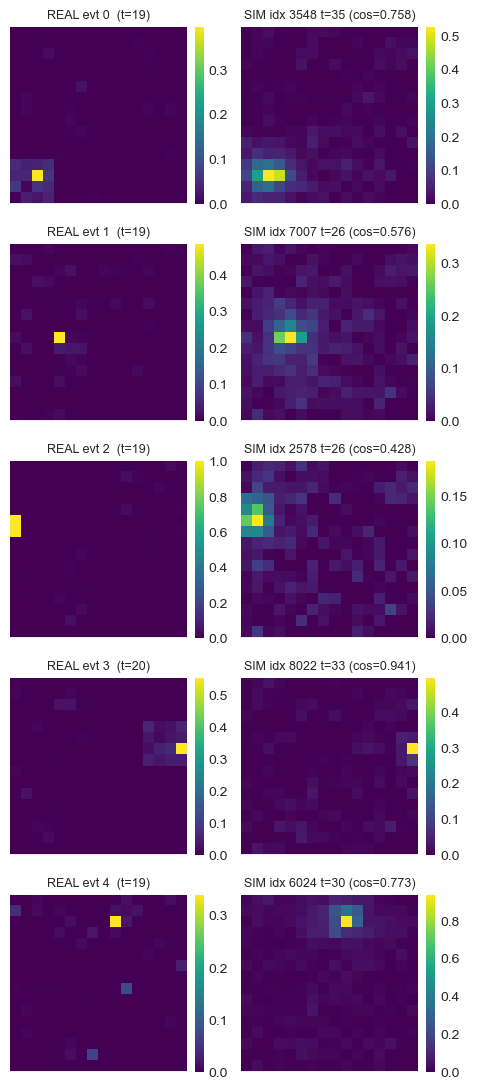

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Peak-frame extractor: (N, T, 16, 16) -> (N, 16, 16), (N,) ----
def peak_frame(cube):
    """Return the time slice holding each event's brightest pixel."""
    N, T, H, W = cube.shape
    flat = cube.reshape(N, T, -1).max(axis=2)      # (N, T) max pixel per frame
    t_peak = flat.argmax(axis=1)                   # (N,)  best time slice
    return cube[np.arange(N), t_peak], t_peak

# ---- Cross-correlation (cosine similarity) match on MAX-PE frames ----
# Extract each event's peak frame, then flatten -> (N, 256)
real_frames, t_real = peak_frame(data_event)           # (200, 16,16), (200,)
sim_frames,  t_sim_all = peak_frame(X_sim_raw)         # (Nsim,16,16), (Nsim,)

def flat(imgs):
    return imgs.reshape(len(imgs), -1)             # (N, 256)

R = flat(real_frames)     # (20,  256)
S = flat(sim_frames)      # (Nsim,256)

# L2-normalize each image so correlation = cosine similarity in [0,1]
def l2norm(A, eps=1e-8):
    return A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)

Rn, Sn = l2norm(R), l2norm(S)

# Cosine similarity matrix (20, Nsim); best match = argmax
corr    = Rn @ Sn.T                              # (20, Nsim)
idx_xc  = np.argmax(corr, axis=1)
sim_xc  = corr[np.arange(len(R)), idx_xc]        # best similarity per real event

# ---- Print matched sim TRUE params ----
tn = ["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]
print(f"{'RealEvt':>7s} {'SimIdx':>7s} {'CosSim':>8s} "
      + " ".join(f"{n:>10s}" for n in tn))
print("-"*82)
for r, (si, c) in enumerate(zip(idx_xc, sim_xc)):
    row = y_sim[si]
    print(f"{r:7d} {si:7d} {c:8.4f} " + " ".join(f"{v:10.3f}" for v in row))

# ---- Side-by-side: max-PE frame, real vs XC-matched sim ----
# Peak frames of the matched sims (their own peak-time slice)
matched_sim_imgs = sim_frames[idx_xc]              # (20, 16, 16)
matched_t_sim    = t_sim_all[idx_xc]               # (20,)

n = 5 #len(X_real)
count = 0
fig, axes = plt.subplots(n, 2, figsize=(5, 2.2 * n))
for r in range(n):
    count += 1
    if count > n:
        break
    ax_r, ax_s = axes[r, 0], axes[r, 1]
    im_r = ax_r.imshow(real_frames[r], origin="lower", cmap="viridis")
    ax_r.set_title(f"REAL evt {r}  (t={t_real[r]})", fontsize=9)
    ax_r.set_xticks([]); ax_r.set_yticks([])
    fig.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)

    im_s = ax_s.imshow(matched_sim_imgs[r], origin="lower", cmap="viridis")
    ax_s.set_title(f"SIM idx {idx_xc[r]} t={matched_t_sim[r]} "
                   f"(cos={sim_xc[r]:.3f})", fontsize=9)
    ax_s.set_xticks([]); ax_s.set_yticks([])
    fig.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig("real_vs_sim_matched_xc_fullcube.png", dpi=120, bbox_inches="tight")
plt.show()

RealEvt  SimIdx   CosSim     log10E    zen_deg     az_deg    tel_x_m    tel_z_m
----------------------------------------------------------------------------------
      0    3537   0.3033      4.050     91.800    272.400      0.300      0.300
      1    1208   0.2914      3.450     89.900    269.700     -0.400     -0.500
      2    2521   0.2573      3.650     90.600    268.800     -0.100     -0.200
      3    3032   0.2903      3.650     89.400    270.300      0.300      3.000
      4     315   0.2087      3.150     89.900    270.300      3.000      1.000
      5    7236   0.1976      4.850     91.200    270.000      0.000      0.000
      6    5453   0.3468      4.550     90.900    271.500      4.000      1.000
      7    7045   0.2160      4.750     91.500    271.200      3.000      0.300
      8    7842   0.2483      4.850     88.800    271.800      3.000      1.000
      9    6127   0.2828      4.650     91.800    271.800      2.000      0.300
     10    3537   0.3222      4.050  

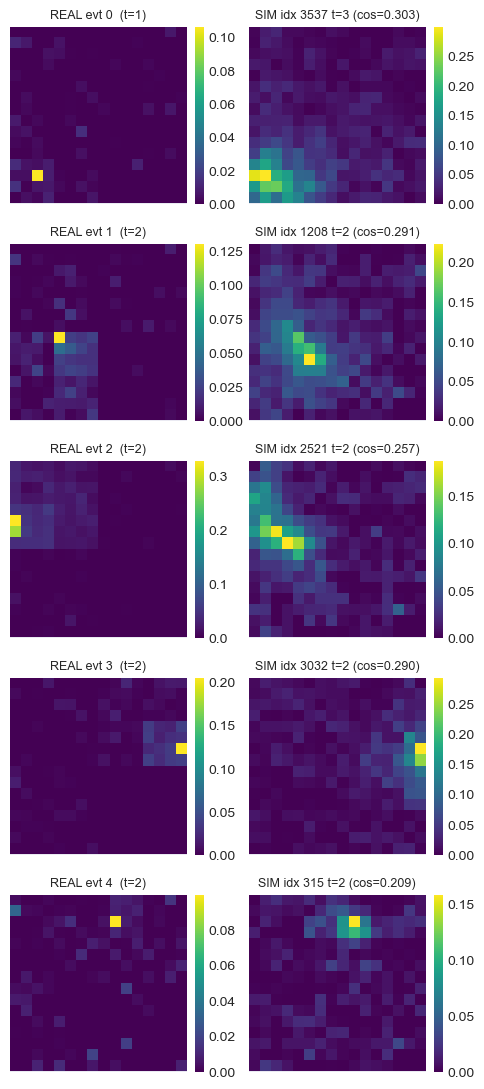

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Full-cube cosine-similarity match (all time frames + all pixels) ----
def flat_cube(X):
    """(N, T, 16, 16) -> (N, T*256)."""
    return X.reshape(len(X), -1)

R = flat_cube(data_event)     # (20,   T*256)
S = flat_cube(X_sim_raw)      # (Nsim, T*256)

def l2norm(A, eps=1e-8):
    return A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)

Rn, Sn = l2norm(R), l2norm(S)

# Cosine similarity matrix (20, Nsim); best match = argmax
corr    = Rn @ Sn.T                              # (20, Nsim)
idx_xc  = np.argmax(corr, axis=1)
sim_xc  = corr[np.arange(len(R)), idx_xc]

# ---- Print matched sim TRUE params ----
tn = ["log10E", "zen_deg", "az_deg", "tel_x_m", "tel_z_m"]
print(f"{'RealEvt':>7s} {'SimIdx':>7s} {'CosSim':>8s} "
      + " ".join(f"{n:>10s}" for n in tn))
print("-"*82)
for r, (si, c) in enumerate(zip(idx_xc, sim_xc)):
    row = y_sim[si]
    print(f"{r:7d} {si:7d} {c:8.4f} " + " ".join(f"{v:10.3f}" for v in row))

# ---- For visualization, still show the peak frame (cube is 4D) ----
def peak_frame(cube):
    N, T, H, W = cube.shape
    flat = cube.reshape(N, T, -1).max(axis=2)
    t_peak = flat.argmax(axis=1)
    return cube[np.arange(N), t_peak], t_peak

real_frames, t_real = peak_frame(X_real)
matched_sim_imgs, matched_t_sim = peak_frame(X_sim[idx_xc])

n = 5 #len(X_real)
count = 0
fig, axes = plt.subplots(n, 2, figsize=(5, 2.2 * n))
for r in range(n):
    count += 1
    if count > n:
        break
    ax_r, ax_s = axes[r, 0], axes[r, 1]
    im_r = ax_r.imshow(real_frames[r], origin="lower", cmap="viridis")
    ax_r.set_title(f"REAL evt {r}  (t={t_real[r]})", fontsize=9)
    ax_r.set_xticks([]); ax_r.set_yticks([])
    fig.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)

    im_s = ax_s.imshow(matched_sim_imgs[r], origin="lower", cmap="viridis")
    ax_s.set_title(f"SIM idx {idx_xc[r]} t={matched_t_sim[r]} "
                   f"(cos={sim_xc[r]:.3f})", fontsize=9)
    ax_s.set_xticks([]); ax_s.set_yticks([])
    fig.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig("real_vs_sim_matched_xc_fullcube.png", dpi=120, bbox_inches="tight")
plt.show()

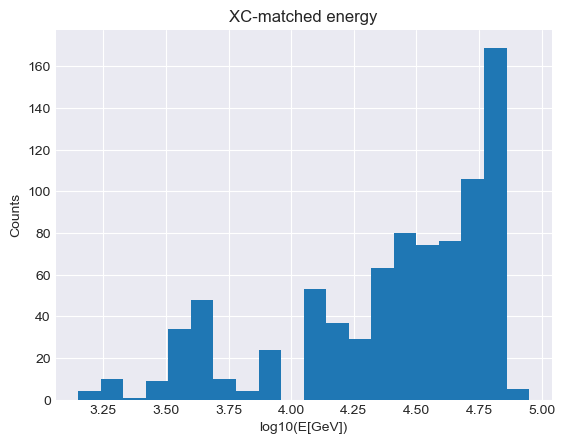

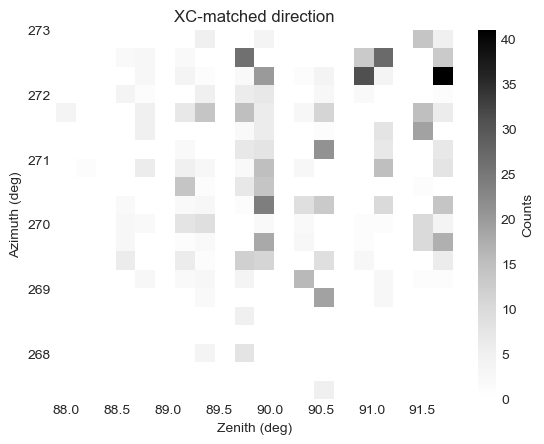

/uufs/chpc.utah.edu/common/home/u1520754/miniconda3/envs/jupyter_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


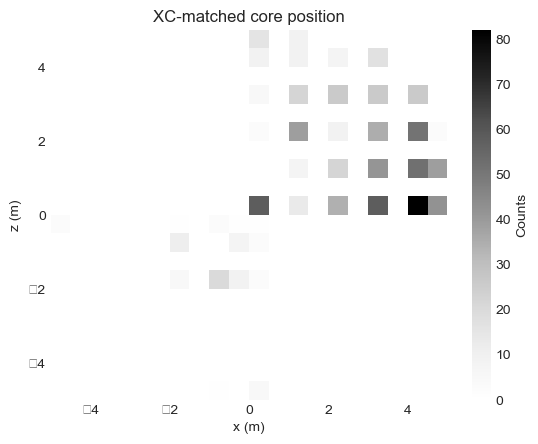

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Cross-correlation "reconstruction" = true params of matched sims ----
xc_params = y_sim[idx_xc]          # (20, 5): log10E, zen, az, x, z

E_recon   = xc_params[:, 0]
zen_recon = xc_params[:, 1]
az_recon  = xc_params[:, 2]
x_recon   = xc_params[:, 3]
z_recon   = xc_params[:, 4]

# ---- 1D: energy ----
plt.hist(E_recon, bins=20)
plt.xlabel("log10(E[GeV])")
plt.ylabel("Counts")
plt.title("XC-matched energy")
plt.show()

# ---- 2D: zenith vs azimuth ----
plt.hist2d(zen_recon, az_recon, bins=20)
plt.xlabel("Zenith (deg)")
plt.ylabel("Azimuth (deg)")
plt.colorbar(label="Counts")
plt.title("XC-matched direction")
plt.show()

# ---- 2D: x vs z ----
plt.hist2d(x_recon, z_recon, bins=20)
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.colorbar(label="Counts")
plt.title("XC-matched core position")
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from ReadTrinity import plot_CARE
import ROOT
from array import array

# ── Config ─────────────────────────────────────────────────────────────────────
BASE_DIR    = "/scratch/general/vast/u1520754/muon_sim_chain_tree"
NSAMP       = 200
NPIX        = 256
BASELINE_DC = 200
DC_TO_PE    = 24.1

MAX_EVENTS    = None
SHARED_CSCALE = True
DATA_SCALE = 150.0

# ── Path builder ────────────────────────────────────────────────────────────────
def care_root_path(pid, E_str, zen, az, h, x, y, z, r, seed):
    return (f"{BASE_DIR}/"
            f"Muon_pid{pid}_E{E_str}_R{r}/pdg{pid}_E{E_str}_r{r}_s{seed}/"
            f"zen{zen}/az{az}/h{h}/x{x}_y{y}_z{z}/CARE/cherenkov_hits.root")

# ── Peak-frame reducer (NaN-safe; matches sim peak-slice logic) ─────────────────
def peak_slice(cube):
    """
    Reduce a (T, nrow, ncol) camera cube to the single (nrow, ncol) frame with
    max total PE. NaN pixels (missing) are ignored in the per-frame sum.
    A 2D input is returned unchanged.
    """
    cube = np.asarray(cube, dtype=np.float64)
    if cube.ndim == 2:
        return cube
    if cube.ndim == 3:
        frame_sums = np.nansum(cube.reshape(cube.shape[0], -1), axis=1)
        t_peak = int(np.argmax(frame_sums))
        return cube[t_peak]
    raise ValueError(f"Unexpected image shape {cube.shape}")

# ── Pixel map builder (from your data-loading code) ────────────────────────────
def build_pixel_map(pixel_config, pixel_pitch=6.25):
    """Build mapping from pixel ID to (row, col) in camera image."""
    xs = [p[1] for p in pixel_config]
    ys = [p[2] for p in pixel_config]
    min_x, min_y = min(xs), min(ys)
    max_x, max_y = max(xs), max(ys)
    ncol = int((max_x - min_x) / pixel_pitch) + 1
    nrow = int((max_y - min_y) / pixel_pitch) + 1

    pixel_map = {}
    for pid, x, y in pixel_config:
        col = int(round((x - min_x) / pixel_pitch))
        row = int(round((y - min_y) / pixel_pitch))
        pixel_map[pid] = (row, col)
    return pixel_map, (nrow, ncol), (min_x, max_x, min_y, max_y)

# ── To camera image (from your data-loading code) ────────────────────────────────
def to_camera_image(values, pixel_map, shape):
    """Convert 1D pixel array to 2D camera image (NaN for missing pixels)."""
    img = np.full(shape, np.nan)
    for pid, v in enumerate(values):
        if pid in pixel_map:
            r, c = pixel_map[pid]
            img[r, c] = v
    return img
    
# ── Jagged trace builder (per-pixel, per-sample) ────────────────────────────────
def extract_traces_jagged(arrays, nsamp=NSAMP, npix=NPIX,
                          baseline_dc=BASELINE_DC, dc_to_pe=DC_TO_PE):
    """
    Build a jagged structure: list of lists.
    traces[pix][sample] = ADC value (int).
    """
    traces = []
    for pix in range(npix):
        key = f"vFADCTraces{pix}"
        if key not in arrays:
            tr = np.zeros(nsamp, dtype=np.int64)
        else:
            tr = np.asarray(arrays[key][0], dtype=np.float64).ravel()
            n = min(len(tr), nsamp)
            # Convert to ADC-like: subtract baseline, convert to int
            tr_adc = np.rint(tr[:n] - baseline_dc).astype(np.int64)
            # Pad if needed
            if n < nsamp:
                tr_adc = np.pad(tr_adc, (0, nsamp - n), mode='constant', constant_values=0)
        traces.append(tr_adc.tolist())  # Convert to list for ROOT jagged storage
    return traces

# ── Side-by-side drawer ──────────────────────────────────────────────────────────
def draw_pair_frame(data_img, sim_img, extent_data, extent_sim, title,
                    data_label="Data (peak frame)", sim_label="Sim (CARE peak)",
                    shared_scale=SHARED_CSCALE):
    vmin = vmax = None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))

    for ax, img, ext, lab in (
        (axes[0], data_img, extent_data, data_label),
        (axes[1], sim_img,  extent_sim,  sim_label),
    ):
        if img is None:
            ax.text(0.5, 0.5, f"{lab}\n(not available)",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color="white")
        im = ax.imshow(np.flip(np.asarray(img, float), axis=0),
                       cmap=cmap, extent=ext, vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax, label="Photoelectron Counts")
        ax.set_title(lab, fontsize=9)
        ax.set_xlabel("Pixel X Position (mm)")
        ax.set_ylabel("Pixel Y Position (mm)")

    fig.suptitle(title, fontsize=9)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig

# ── Main collector (with jagged branch) ───────────────────────────────────────────
def collect_matched_sims_datalike(idx, meta_sim, data_event, dest_dir,
                                   pid=particle_id, r=radius, y_tel=0,
                                   max_events=MAX_EVENTS,
                                   data_scale=DATA_SCALE,
                                   data_extent=None,
                                   root_name="matched_sims_datalike.root",
                                   pdf_name="matched_sims_peakframes.pdf"):
    """
    Store sim traces as jagged arrays (matching real-data structure):
    Events/Event/signalValue : jagged array, events × pixels × samples
    """
    os.makedirs(dest_dir, exist_ok=True)
    out_root = os.path.join(dest_dir, root_name)
    out_pdf  = os.path.join(dest_dir, pdf_name)

    fout = ROOT.TFile(out_root, "RECREATE")
    d = fout.mkdir("Events"); d.cd()
    tree = ROOT.TTree("Event", "Matched sim traces (jagged, data-like format)")

    n_pix   = array('i', [0])
    n_samp  = array('i', [0])
    
    # Create a jagged branch: TVectorT<int> to store variable-length traces
    tree.Branch("nPixel",  n_pix,  "nPixel/I")
    tree.Branch("nSample", n_samp, "nSample/I")
    
    # Use a vector of vectors for jagged structure
    sig_vec = ROOT.std.vector(ROOT.std.vector('int'))()
    tree.Branch("signalValue", sig_vec)

    summary = []
    pdf = PdfPages(out_pdf)
    stored = 0

    n_data = len(data_event)

    for r_i, entry in enumerate(idx):
        if max_events is not None and stored >= max_events:
            break

        si = int(entry)
        di = r_i

        m = meta_sim[si]
        m = m.item() if hasattr(m, "item") else m

        zen_s = normalize_angle_number(m["zen"])
        az_s  = normalize_angle_number(m["az"])
        h_s   = normalize_path_number_h(m["h"])
        x_s   = normalize_path_number(m["x"])
        z_s   = normalize_path_number(m["z"])

        src = care_root_path(pid, m["E_str"], zen_s, az_s,
                             h_s, x_s, y_tel, z_s, r, m["seed"])

        if not os.path.isfile(src):
            print(f"[{r_i}] MISSING source, skipping: {src}")
            summary.append((r_i, si, di, "missing_src"))
            continue

        try:
            cm, time_ns, total_pe, max_pe, arrays, pixel_config_r, \
                min_x, max_x, min_y, max_y, pixel_pitch = plot_CARE(src, plot=False)
        except Exception as e:
            print(f"[{r_i}] WARNING: could not read: {e}")
            summary.append((r_i, si, di, "read_fail"))
            continue

        try:
            traces = extract_traces_jagged(arrays)  # List of lists
        except Exception as e:
            print(f"[{r_i}] WARNING: could not build traces: {e}")
            summary.append((r_i, si, di, "trace_fail"))
            continue

        # ── Fill ROOT branches ───────────────────────────────────────────────
        n_pix[0]  = NPIX
        n_samp[0] = NSAMP
        
        # Clear and fill jagged vector
        sig_vec.clear()
        for pixel_samples in traces:
            pix_vec = ROOT.std.vector('int')()
            for sample in pixel_samples:
                pix_vec.push_back(int(sample))
            sig_vec.push_back(pix_vec)
        
        tree.Fill()

        # ── Peak-frame images (both NaN-safe) ────────────────────────────
        sim_extent = (min_x, max_x, min_y, max_y)
        sim_img    = peak_slice(cm)

        # data indexed by real-event position r_i, scaled back to PE
        data_img = None
        if 0 <= di < n_data:
            try:
                data_img = peak_slice(data_event[di]) * data_scale
            except Exception as e:
                print(f"[{r_i}] WARNING: no data image for di={di}: "
                      f"{type(e).__name__}: {e}")
        else:
            print(f"[{r_i}] di={di} out of range (data_event has {n_data})")

        d_ext = data_extent if data_extent is not None else sim_extent

        title = (f"sim{si} / data{di}  E{m['E_str']} zen{m['zen']} az{m['az']} "
                 f"x{m['x']} y{y_tel} z{m['z']} seed{m['seed']}")

        fig = draw_pair_frame(data_img, sim_img, d_ext, sim_extent, title)
        if data_img is not None and sim_img is not None:
            print(f"  Data max: {np.nanmax(data_img):.1f}  Sim max: {np.nanmax(sim_img):.1f}")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        stored += 1
        print(f"[{r_i}] OK  sim {si}  data {di}")
        summary.append((r_i, si, di, "stored"))

    fout.cd(); d.cd()
    tree.Write()
    fout.Close()
    pdf.close()

    print("\n=== Summary ===")
    for r_i, si, di, status in summary:
        print(f"  match {r_i:2d}  sim {si:4d}  data {di:4d}  {status}")
    print(f"\nStored events : {stored}")
    print(f"ROOT file     : {out_root}")
    print(f"PDF  file     : {out_pdf}")
    return summary

# ── Run it ────────────────────────────────────────────────────────────────────
DEST_DIR = "/uufs/chpc.utah.edu/common/home/u1520754/Data/matched_sims"
meta_sim = sim["meta"]

collect_matched_sims_datalike(idx_xc, meta_sim, data_event, DEST_DIR)

/tmp/ipykernel_1306073/3715797604.py:119: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.tight_layout(rect=(0, 0, 1, 0.95))
/tmp/ipykernel_1306073/3715797604.py:235: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  pdf.savefig(fig, bbox_inches="tight")


  Data max: 44.1  Sim max: 64.0
[0] OK  sim 3537  data 0
  Data max: 54.9  Sim max: 42.0
[1] OK  sim 1208  data 1
  Data max: 149.6  Sim max: 33.0
[2] OK  sim 2521  data 2
  Data max: 53.8  Sim max: 60.0
[3] OK  sim 3032  data 3
  Data max: 47.1  Sim max: 30.0
[4] OK  sim 315  data 4
  Data max: 34.0  Sim max: 43.0
[5] OK  sim 7236  data 5
  Data max: 67.4  Sim max: 29.0
[6] OK  sim 5453  data 6
  Data max: 52.6  Sim max: 24.0
[7] OK  sim 7045  data 7
  Data max: 70.5  Sim max: 52.0
[8] OK  sim 7842  data 8
  Data max: 69.2  Sim max: 22.0
[9] OK  sim 6127  data 9
  Data max: 93.5  Sim max: 64.0
[10] OK  sim 3537  data 10
  Data max: 39.0  Sim max: 34.0
[11] OK  sim 8331  data 11
  Data max: 30.7  Sim max: 24.0
[12] OK  sim 6254  data 12
  Data max: 63.9  Sim max: 30.0
[13] OK  sim 5481  data 13
  Data max: 5.8  Sim max: 61.0
[14] OK  sim 2679  data 14
  Data max: 51.0  Sim max: 31.0
[15] OK  sim 232  data 15
  Data max: 150.0  Sim max: 38.0
[16] OK  sim 2555  data 16
  Data max: 150.0 

[(0, 3537, 0, 'stored'),
 (1, 1208, 1, 'stored'),
 (2, 2521, 2, 'stored'),
 (3, 3032, 3, 'stored'),
 (4, 315, 4, 'stored'),
 (5, 7236, 5, 'stored'),
 (6, 5453, 6, 'stored'),
 (7, 7045, 7, 'stored'),
 (8, 7842, 8, 'stored'),
 (9, 6127, 9, 'stored'),
 (10, 3537, 10, 'stored'),
 (11, 8331, 11, 'stored'),
 (12, 6254, 12, 'stored'),
 (13, 5481, 13, 'stored'),
 (14, 2679, 14, 'stored'),
 (15, 232, 15, 'stored'),
 (16, 2555, 16, 'stored'),
 (17, 4628, 17, 'stored'),
 (18, 4082, 18, 'stored'),
 (19, 5491, 19, 'stored'),
 (20, 6102, 20, 'stored'),
 (21, 5481, 21, 'stored'),
 (22, 3066, 22, 'stored'),
 (23, 2664, 23, 'stored'),
 (24, 4179, 24, 'stored'),
 (25, 2652, 25, 'stored'),
 (26, 2652, 26, 'stored'),
 (27, 3537, 27, 'stored'),
 (28, 5969, 28, 'stored'),
 (29, 3537, 29, 'stored'),
 (30, 7502, 30, 'stored'),
 (31, 2584, 31, 'stored'),
 (32, 6254, 32, 'stored'),
 (33, 7233, 33, 'stored'),
 (34, 8313, 34, 'stored'),
 (35, 7233, 35, 'stored'),
 (36, 7233, 36, 'stored'),
 (37, 7233, 37, 'stored

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from ReadTrinity import plot_CARE
import ROOT
from array import array

# ── Config ─────────────────────────────────────────────────────────────────────
BASE_DIR    = "/scratch/general/vast/u1520754/muon_sim_chain_tree"
NSAMP       = 200
NPIX        = 256
BASELINE_DC = 200
DC_TO_PE    = 24.1

MAX_EVENTS    = 100
SHARED_CSCALE = True
DATA_SCALE = 150.0

# ── Path builder ────────────────────────────────────────────────────────────────
def care_root_path(pid, E_str, zen, az, h, x, y, z, r, seed):
    return (f"{BASE_DIR}/"
            f"Muon_pid{pid}_E{E_str}_R{r}/pdg{pid}_E{E_str}_r{r}_s{seed}/"
            f"zen{zen}/az{az}/h{h}/x{x}_y{y}_z{z}/CARE/cherenkov_hits.root")

# ── Peak-frame reducer (NaN-safe; matches sim peak-slice logic) ─────────────────
def peak_slice(cube):
    """
    Reduce a (T, nrow, ncol) camera cube to the single (nrow, ncol) frame with
    max total PE. NaN pixels (missing) are ignored in the per-frame sum.
    A 2D input is returned unchanged.
    """
    cube = np.asarray(cube, dtype=np.float64)
    if cube.ndim == 2:
        return cube
    if cube.ndim == 3:
        frame_sums = np.nansum(cube.reshape(cube.shape[0], -1), axis=1)
        t_peak = int(np.argmax(frame_sums))
        return cube[t_peak]
    raise ValueError(f"Unexpected image shape {cube.shape}")

# ── Pixel map builder (from your data-loading code) ────────────────────────────
def build_pixel_map(pixel_config, pixel_pitch=6.25):
    """Build mapping from pixel ID to (row, col) in camera image."""
    xs = [p[1] for p in pixel_config]
    ys = [p[2] for p in pixel_config]
    min_x, min_y = min(xs), min(ys)
    max_x, max_y = max(xs), max(ys)
    ncol = int((max_x - min_x) / pixel_pitch) + 1
    nrow = int((max_y - min_y) / pixel_pitch) + 1

    pixel_map = {}
    for pid, x, y in pixel_config:
        col = int(round((x - min_x) / pixel_pitch))
        row = int(round((y - min_y) / pixel_pitch))
        pixel_map[pid] = (row, col)
    return pixel_map, (nrow, ncol), (min_x, max_x, min_y, max_y)

# ── To camera image (from your data-loading code) ────────────────────────────────
def to_camera_image(values, pixel_map, shape):
    """Convert 1D pixel array to 2D camera image (NaN for missing pixels)."""
    img = np.full(shape, np.nan)
    for pid, v in enumerate(values):
        if pid in pixel_map:
            r, c = pixel_map[pid]
            img[r, c] = v
    return img

# ── Store CARE data with baseline subtraction ────────────────────────────────────
def store_care_event(event_group, arrays, baseline_subtract=200):
    """
    Store all CARE branches in the event group, subtracting baseline from traces.
    
    Args:
        event_group: ROOT TDirectory for this event
        arrays: dict of numpy arrays from plot_CARE
        baseline_subtract: value to subtract from all vFADCTraces
    """
    event_group.cd()
    
    # Store vPEInPixel (integrated PE per pixel)
    if "vPEInPixel" in arrays:
        pe_array = arrays["vPEInPixel"][0]
        pe_vec = ROOT.std.vector('float')()
        for val in pe_array:
            pe_vec.push_back(float(val))
        # Store as a simple branch
        pe_vec_copy = pe_vec  # Keep reference alive
    
    # Store all 256 vFADCTraces with baseline subtraction
    traces_dict = {}
    for pix in range(256):
        key = f"vFADCTraces{pix}"
        if key in arrays:
            trace = np.asarray(arrays[key][0], dtype=np.float64).ravel()
            # Subtract baseline
            trace_corrected = trace - baseline_subtract
            traces_dict[key] = trace_corrected
        else:
            traces_dict[key] = np.zeros(NSAMP)
    
    return traces_dict

# ── Side-by-side drawer ──────────────────────────────────────────────────────────
def draw_pair_frame(data_img, sim_img, extent_data, extent_sim, title,
                    data_label="Data (peak frame)", sim_label="Sim (CARE peak)",
                    shared_scale=SHARED_CSCALE):
    vmin = vmax = None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))

    for ax, img, ext, lab in (
        (axes[0], data_img, extent_data, data_label),
        (axes[1], sim_img,  extent_sim,  sim_label),
    ):
        if img is None:
            ax.text(0.5, 0.5, f"{lab}\n(not available)",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color="white")
        im = ax.imshow(np.flip(np.asarray(img, float), axis=0),
                       cmap=cmap, extent=ext, vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax, label="Photoelectron Counts")
        ax.set_title(lab, fontsize=9)
        ax.set_xlabel("Pixel X Position (mm)")
        ax.set_ylabel("Pixel Y Position (mm)")

    fig.suptitle(title, fontsize=9)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig

# ── Main collector (preserves full CARE ROOT structure) ─────────────────────────
def collect_matched_sims_datalike(idx, meta_sim, data_event, dest_dir,
                                   pid=particle_id, r=radius, y_tel=0,
                                   max_events=MAX_EVENTS,
                                   data_scale=DATA_SCALE,
                                   data_extent=None,
                                   root_name="matched_sims_datalike.root",
                                   pdf_name="matched_sims_peakframes.pdf"):
    """
    Store matched sim events preserving full CARE ROOT structure.
    Each event gets its own directory with all vFADCTraces and vPEInPixel.
    
    Structure:
        matched_sims_datalike.root
        ├── Events/
        │   ├── Event_0/
        │   │   ├── vPEInPixel (vector<float>)
        │   │   ├── vFADCTraces0 (vector<float>, baseline-subtracted)
        │   │   ├── vFADCTraces1
        │   │   └── ... [256 traces total]
        │   ├── Event_1/
        │   └── ...
    """
    os.makedirs(dest_dir, exist_ok=True)
    out_root = os.path.join(dest_dir, root_name)
    out_pdf  = os.path.join(dest_dir, pdf_name)

    fout = ROOT.TFile(out_root, "RECREATE")
    events_dir = fout.mkdir("Events")
    
    summary = []
    pdf = PdfPages(out_pdf)
    stored = 0

    n_data = len(data_event)

    for r_i, entry in enumerate(idx):
        if max_events is not None and stored >= max_events:
            break

        si = int(entry)
        di = r_i

        m = meta_sim[si]
        m = m.item() if hasattr(m, "item") else m

        zen_s = normalize_angle_number(m["zen"])
        az_s  = normalize_angle_number(m["az"])
        h_s   = normalize_path_number_h(m["h"])
        x_s   = normalize_path_number(m["x"])
        z_s   = normalize_path_number(m["z"])

        src = care_root_path(pid, m["E_str"], zen_s, az_s,
                             h_s, x_s, y_tel, z_s, r, m["seed"])

        if not os.path.isfile(src):
            print(f"[{r_i}] MISSING source, skipping: {src}")
            summary.append((r_i, si, di, "missing_src"))
            continue

        try:
            cm, time_ns, total_pe, max_pe, arrays, pixel_config_r, \
                min_x, max_x, min_y, max_y, pixel_pitch = plot_CARE(src, plot=False)
        except Exception as e:
            print(f"[{r_i}] WARNING: could not read: {e}")
            summary.append((r_i, si, di, "read_fail"))
            continue

        try:
            traces_dict = store_care_event(events_dir, arrays, baseline_subtract=200)
        except Exception as e:
            print(f"[{r_i}] WARNING: could not store CARE data: {e}")
            summary.append((r_i, si, di, "store_fail"))
            continue

        # ── Create event-specific directory and store all branches ───────────
        event_dir = events_dir.mkdir(f"Event_{stored}")
        event_dir.cd()
        
        # Store vPEInPixel
        pe_array = arrays["vPEInPixel"][0]
        pe_vec = ROOT.std.vector('float')()
        for val in pe_array:
            pe_vec.push_back(float(val))
        # Create a simple way to store: use a TTree with one entry
        pe_tree = ROOT.TTree("CARE", "CARE data")
        pe_branch = ROOT.std.vector('float')()
        pe_tree.Branch("vPEInPixel", pe_branch)
        for val in pe_array:
            pe_branch.push_back(float(val))
        pe_tree.Fill()
        pe_tree.Write()
        
        # Store all 256 traces with baseline subtraction
        for pix in range(256):
            key = f"vFADCTraces{pix}"
            trace_vec = ROOT.std.vector('float')()
            
            if key in traces_dict:
                trace = traces_dict[key]
                for sample in trace:
                    trace_vec.push_back(float(sample))
            else:
                for _ in range(NSAMP):
                    trace_vec.push_back(0.0)
            
            # Store in a parallel TTree structure
            trace_tree = ROOT.TTree(key, f"Trace for pixel {pix}")
            trace_branch = ROOT.std.vector('float')()
            trace_tree.Branch(key, trace_branch)
            for sample in trace_vec:
                trace_branch.push_back(sample)
            trace_tree.Fill()
            trace_tree.Write()
        
        # ── Peak-frame images (both NaN-safe) for PDF ────────────────────────
        sim_extent = (min_x, max_x, min_y, max_y)
        sim_img    = peak_slice(cm)

        # data indexed by real-event position r_i, scaled back to PE
        data_img = None
        if 0 <= di < n_data:
            try:
                data_img = peak_slice(data_event[di]) * data_scale
            except Exception as e:
                print(f"[{r_i}] WARNING: no data image for di={di}: "
                      f"{type(e).__name__}: {e}")
        else:
            print(f"[{r_i}] di={di} out of range (data_event has {n_data})")

        d_ext = data_extent if data_extent is not None else sim_extent

        title = (f"sim{si} / data{di}  E{m['E_str']} zen{m['zen']} az{m['az']} "
                 f"x{m['x']} y{y_tel} z{m['z']} seed{m['seed']}")

        fig = draw_pair_frame(data_img, sim_img, d_ext, sim_extent, title)
        if data_img is not None and sim_img is not None:
            print(f"  Data max: {np.nanmax(data_img):.1f}  Sim max: {np.nanmax(sim_img):.1f}")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        stored += 1
        print(f"[{r_i}] OK  sim {si}  data {di}")
        summary.append((r_i, si, di, "stored"))

    fout.cd()
    fout.Write()
    fout.Close()
    pdf.close()

    print("\n=== Summary ===")
    for r_i, si, di, status in summary:
        print(f"  match {r_i:2d}  sim {si:4d}  data {di:4d}  {status}")
    print(f"\nStored events : {stored}")
    print(f"ROOT file     : {out_root}")
    print(f"PDF  file     : {out_pdf}")
    return summary

# ── Run it ────────────────────────────────────────────────────────────────────
DEST_DIR = "/uufs/chpc.utah.edu/common/home/u1520754/Data/matched_sims"
meta_sim = sim["meta"]

collect_matched_sims_datalike(idx_xc, meta_sim, data_event, DEST_DIR)

/tmp/ipykernel_1404603/959359805.py:131: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  fig.tight_layout(rect=(0, 0, 1, 0.95))
/tmp/ipykernel_1404603/959359805.py:272: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Arial.
  pdf.savefig(fig, bbox_inches="tight")


  Data max: 44.1  Sim max: 64.0
[0] OK  sim 3537  data 0
  Data max: 54.9  Sim max: 42.0
[1] OK  sim 1208  data 1
  Data max: 149.6  Sim max: 33.0
[2] OK  sim 2521  data 2
  Data max: 53.8  Sim max: 60.0
[3] OK  sim 3032  data 3
  Data max: 47.1  Sim max: 30.0
[4] OK  sim 315  data 4
  Data max: 34.0  Sim max: 43.0
[5] OK  sim 7236  data 5
  Data max: 67.4  Sim max: 29.0
[6] OK  sim 5453  data 6
  Data max: 52.6  Sim max: 24.0
[7] OK  sim 7045  data 7
  Data max: 70.5  Sim max: 52.0
[8] OK  sim 7842  data 8
  Data max: 69.2  Sim max: 22.0
[9] OK  sim 6127  data 9
  Data max: 93.5  Sim max: 64.0
[10] OK  sim 3537  data 10
  Data max: 39.0  Sim max: 34.0
[11] OK  sim 8331  data 11
  Data max: 30.7  Sim max: 24.0
[12] OK  sim 6254  data 12
  Data max: 63.9  Sim max: 30.0
[13] OK  sim 5481  data 13
  Data max: 5.8  Sim max: 61.0
[14] OK  sim 2679  data 14
  Data max: 51.0  Sim max: 31.0
[15] OK  sim 232  data 15
  Data max: 150.0  Sim max: 38.0
[16] OK  sim 2555  data 16
  Data max: 150.0 

[(0, 3537, 0, 'stored'),
 (1, 1208, 1, 'stored'),
 (2, 2521, 2, 'stored'),
 (3, 3032, 3, 'stored'),
 (4, 315, 4, 'stored'),
 (5, 7236, 5, 'stored'),
 (6, 5453, 6, 'stored'),
 (7, 7045, 7, 'stored'),
 (8, 7842, 8, 'stored'),
 (9, 6127, 9, 'stored'),
 (10, 3537, 10, 'stored'),
 (11, 8331, 11, 'stored'),
 (12, 6254, 12, 'stored'),
 (13, 5481, 13, 'stored'),
 (14, 2679, 14, 'stored'),
 (15, 232, 15, 'stored'),
 (16, 2555, 16, 'stored'),
 (17, 4628, 17, 'stored'),
 (18, 4082, 18, 'stored'),
 (19, 5491, 19, 'stored'),
 (20, 6102, 20, 'stored'),
 (21, 5481, 21, 'stored'),
 (22, 3066, 22, 'stored'),
 (23, 2664, 23, 'stored'),
 (24, 4179, 24, 'stored'),
 (25, 2652, 25, 'stored'),
 (26, 2652, 26, 'stored'),
 (27, 3537, 27, 'stored'),
 (28, 5969, 28, 'stored'),
 (29, 3537, 29, 'stored'),
 (30, 7502, 30, 'stored'),
 (31, 2584, 31, 'stored'),
 (32, 6254, 32, 'stored'),
 (33, 7233, 33, 'stored'),
 (34, 8313, 34, 'stored'),
 (35, 7233, 35, 'stored'),
 (36, 7233, 36, 'stored'),
 (37, 7233, 37, 'stored

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from ReadTrinity import plot_CARE
import ROOT
from array import array

# ── Config ─────────────────────────────────────────────────────────────────────
BASE_DIR    = "/scratch/general/vast/u1520754/muon_sim_chain_tree"
NSAMP       = 200
NPIX        = 256
BASELINE_DC = 200
DC_TO_PE    = 24.1

SHARED_CSCALE = True
DATA_SCALE = 150.0

# ── Event range (store events from START_EVENT to END_EVENT, exclusive) ─────────
START_EVENT = 0      # first match index to store (inclusive)
END_EVENT   = 200    # last match index to store (exclusive); use None for all

# ── Path builder ────────────────────────────────────────────────────────────────
def care_root_path(pid, E_str, zen, az, h, x, y, z, r, seed):
    return (f"{BASE_DIR}/"
            f"Muon_pid{pid}_E{E_str}_R{r}/pdg{pid}_E{E_str}_r{r}_s{seed}/"
            f"zen{zen}/az{az}/h{h}/x{x}_y{y}_z{z}/CARE/cherenkov_hits.root")

# ── Peak-frame reducer (NaN-safe; matches sim peak-slice logic) ─────────────────
def peak_slice(cube):
    """
    Reduce a (T, nrow, ncol) camera cube to the single (nrow, ncol) frame with
    max total PE. NaN pixels (missing) are ignored in the per-frame sum.
    A 2D input is returned unchanged.
    """
    cube = np.asarray(cube, dtype=np.float64)
    if cube.ndim == 2:
        return cube
    if cube.ndim == 3:
        frame_sums = np.nansum(cube.reshape(cube.shape[0], -1), axis=1)
        t_peak = int(np.argmax(frame_sums))
        return cube[t_peak]
    raise ValueError(f"Unexpected image shape {cube.shape}")

# ── Pixel map builder (from your data-loading code) ────────────────────────────
def build_pixel_map(pixel_config, pixel_pitch=6.25):
    """Build mapping from pixel ID to (row, col) in camera image."""
    xs = [p[1] for p in pixel_config]
    ys = [p[2] for p in pixel_config]
    min_x, min_y = min(xs), min(ys)
    max_x, max_y = max(xs), max(ys)
    ncol = int((max_x - min_x) / pixel_pitch) + 1
    nrow = int((max_y - min_y) / pixel_pitch) + 1

    pixel_map = {}
    for pid, x, y in pixel_config:
        col = int(round((x - min_x) / pixel_pitch))
        row = int(round((y - min_y) / pixel_pitch))
        pixel_map[pid] = (row, col)
    return pixel_map, (nrow, ncol), (min_x, max_x, min_y, max_y)

# ── To camera image (from your data-loading code) ────────────────────────────────
def to_camera_image(values, pixel_map, shape):
    """Convert 1D pixel array to 2D camera image (NaN for missing pixels)."""
    img = np.full(shape, np.nan)
    for pid, v in enumerate(values):
        if pid in pixel_map:
            r, c = pixel_map[pid]
            img[r, c] = v
    return img

# ── Jagged trace builder (per-pixel, per-sample) ────────────────────────────────
def extract_traces_jagged(arrays, nsamp=NSAMP, npix=NPIX,
                          baseline_dc=BASELINE_DC, dc_to_pe=DC_TO_PE):
    """
    Build a jagged structure: list of lists.
    traces[pix][sample] = ADC value (int).
    """
    traces = []
    for pix in range(npix):
        key = f"vFADCTraces{pix}"
        if key not in arrays:
            tr = np.zeros(nsamp, dtype=np.int64)
        else:
            tr = np.asarray(arrays[key][0], dtype=np.float64).ravel()
            n = min(len(tr), nsamp)
            # Convert to ADC-like: subtract baseline, convert to int
            tr_adc = np.rint(tr[:n] - baseline_dc).astype(np.int64)
            # Pad if needed
            if n < nsamp:
                tr_adc = np.pad(tr_adc, (0, nsamp - n), mode='constant', constant_values=0)
        traces.append(tr_adc.tolist())  # Convert to list for ROOT jagged storage
    return traces

# ── Side-by-side drawer ──────────────────────────────────────────────────────────
def draw_pair_frame(data_img, sim_img, extent_data, extent_sim, title,
                    data_label="Data (peak frame)", sim_label="Sim (CARE peak)",
                    shared_scale=SHARED_CSCALE):
    vmin = vmax = None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))

    for ax, img, ext, lab in (
        (axes[0], data_img, extent_data, data_label),
        (axes[1], sim_img,  extent_sim,  sim_label),
    ):
        if img is None:
            ax.text(0.5, 0.5, f"{lab}\n(not available)",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue
        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color="white")
        im = ax.imshow(np.flip(np.asarray(img, float), axis=0),
                       cmap=cmap, extent=ext, vmin=vmin, vmax=vmax)
        fig.colorbar(im, ax=ax, label="Photoelectron Counts")
        ax.set_title(lab, fontsize=9)
        ax.set_xlabel("Pixel X Position (mm)")
        ax.set_ylabel("Pixel Y Position (mm)")

    fig.suptitle(title, fontsize=9)
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig

# ── Main collector (with jagged branch + event-range selection) ────────────────
def collect_matched_sims_datalike(idx, meta_sim, data_event, dest_dir,
                                   pid=particle_id, r=radius, y_tel=0,
                                   start_event=START_EVENT,
                                   end_event=END_EVENT,
                                   data_scale=DATA_SCALE,
                                   data_extent=None,
                                   root_name=None,
                                   pdf_name=None):
    """
    Store sim traces as jagged arrays (matching real-data structure):
    Events/Event/signalValue : jagged array, events × pixels × samples

    Only match indices in [start_event, end_event) are processed.
    Set end_event=None to process through the end of idx.
    Output file names include the event range if not explicitly given.
    """
    os.makedirs(dest_dir, exist_ok=True)

    # Resolve range against the length of idx
    n_idx = len(idx)
    lo = max(0, int(start_event))
    hi = n_idx if end_event is None else min(n_idx, int(end_event))
    if lo >= hi:
        raise ValueError(f"Empty event range: start={lo}, end={hi} (idx len={n_idx})")

    # Auto-name output files with the range if not provided
    if root_name is None:
        root_name = f"matched_sims_datalike_{lo}_{hi}.root"
    if pdf_name is None:
        pdf_name = f"matched_sims_peakframes_{lo}_{hi}.pdf"

    out_root = os.path.join(dest_dir, root_name)
    out_pdf  = os.path.join(dest_dir, pdf_name)

    fout = ROOT.TFile(out_root, "RECREATE")
    d = fout.mkdir("Events"); d.cd()
    tree = ROOT.TTree("Event", "Matched sim traces (jagged, data-like format)")

    n_pix   = array('i', [0])
    n_samp  = array('i', [0])
    match_i = array('i', [0])   # store the global match index for traceability

    tree.Branch("nPixel",  n_pix,  "nPixel/I")
    tree.Branch("nSample", n_samp, "nSample/I")
    tree.Branch("matchIndex", match_i, "matchIndex/I")

    # Use a vector of vectors for jagged structure
    sig_vec = ROOT.std.vector(ROOT.std.vector('int'))()
    tree.Branch("signalValue", sig_vec)

    summary = []
    pdf = PdfPages(out_pdf)
    stored = 0

    n_data = len(data_event)

    print(f"Processing match indices [{lo}, {hi}) out of {n_idx} total\n")

    # Only iterate over the requested slice; keep true global index r_i
    for r_i in range(lo, hi):
        entry = idx[r_i]

        si = int(entry)
        di = r_i

        m = meta_sim[si]
        m = m.item() if hasattr(m, "item") else m

        zen_s = normalize_angle_number(m["zen"])
        az_s  = normalize_angle_number(m["az"])
        h_s   = normalize_path_number_h(m["h"])
        x_s   = normalize_path_number(m["x"])
        z_s   = normalize_path_number(m["z"])

        src = care_root_path(pid, m["E_str"], zen_s, az_s,
                             h_s, x_s, y_tel, z_s, r, m["seed"])

        if not os.path.isfile(src):
            print(f"[{r_i}] MISSING source, skipping: {src}")
            summary.append((r_i, si, di, "missing_src"))
            continue

        try:
            cm, time_ns, total_pe, max_pe, arrays, pixel_config_r, \
                min_x, max_x, min_y, max_y, pixel_pitch = plot_CARE(src, plot=False)
        except Exception as e:
            print(f"[{r_i}] WARNING: could not read: {e}")
            summary.append((r_i, si, di, "read_fail"))
            continue

        try:
            traces = extract_traces_jagged(arrays)  # List of lists
        except Exception as e:
            print(f"[{r_i}] WARNING: could not build traces: {e}")
            summary.append((r_i, si, di, "trace_fail"))
            continue

        # ── Fill ROOT branches ───────────────────────────────────────────────
        n_pix[0]   = NPIX
        n_samp[0]  = NSAMP
        match_i[0] = r_i

        # Clear and fill jagged vector
        sig_vec.clear()
        for pixel_samples in traces:
            pix_vec = ROOT.std.vector('int')()
            for sample in pixel_samples:
                pix_vec.push_back(int(sample))
            sig_vec.push_back(pix_vec)

        tree.Fill()

        # ── Peak-frame images (both NaN-safe) ────────────────────────────
        sim_extent = (min_x, max_x, min_y, max_y)
        sim_img    = peak_slice(cm)

        # data indexed by real-event position r_i, scaled back to PE
        data_img = None
        if 0 <= di < n_data:
            try:
                data_img = peak_slice(data_event[di]) * data_scale
            except Exception as e:
                print(f"[{r_i}] WARNING: no data image for di={di}: "
                      f"{type(e).__name__}: {e}")
        else:
            print(f"[{r_i}] di={di} out of range (data_event has {n_data})")

        d_ext = data_extent if data_extent is not None else sim_extent

        title = (f"sim{si} / data{di}  E{m['E_str']} zen{m['zen']} az{m['az']} "
                 f"x{m['x']} y{y_tel} z{m['z']} seed{m['seed']}")

        fig = draw_pair_frame(data_img, sim_img, d_ext, sim_extent, title)
        if data_img is not None and sim_img is not None:
            print(f"  Data max: {np.nanmax(data_img):.1f}  Sim max: {np.nanmax(sim_img):.1f}")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        stored += 1
        print(f"[{r_i}] OK  sim {si}  data {di}")
        summary.append((r_i, si, di, "stored"))

    fout.cd(); d.cd()
    tree.Write()
    fout.Close()
    pdf.close()

    print("\n=== Summary ===")
    for r_i, si, di, status in summary:
        print(f"  match {r_i:4d}  sim {si:4d}  data {di:4d}  {status}")
    print(f"\nRange requested : [{lo}, {hi})")
    print(f"Stored events   : {stored}")
    print(f"ROOT file       : {out_root}")
    print(f"PDF  file       : {out_pdf}")
    return summary

# ── Run it ────────────────────────────────────────────────────────────────────
DEST_DIR = "/uufs/chpc.utah.edu/common/home/u1520754/Data/matched_sims"
meta_sim = sim["meta"]

# Store events from START_EVENT to END_EVENT (set at top of file).
# Examples:
#   START_EVENT, END_EVENT = 0, 200     -> first 200 matches
#   START_EVENT, END_EVENT = 300, 400   -> matches 300..399
#   START_EVENT, END_EVENT = 0, None    -> all matches
collect_matched_sims_datalike(idx_xc, meta_sim, data_event, DEST_DIR,
                              start_event=START_EVENT,
                              end_event=END_EVENT)